In [1]:
import os
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import sys
sys.path.append('.')
from utils.dataset import LMDBDatabase

## Dataset Stat

In [6]:
db_name = 'bpep'
meta_path = f'data_train/{db_name}/dfs/meta_uni.csv'
df_meta_bpep = pd.read_csv(meta_path)

db_name = 'cpep'
meta_path = f'data_train/{db_name}/dfs/meta_uni.csv'
df_meta_cpep = pd.read_csv(meta_path)

In [7]:
# remove abnormal data_ids
remove_data_ids = ['cpep_8ebk', 'cpep_7yuz']
df_meta_cpep = df_meta_cpep[~df_meta_cpep['data_id'].isin(remove_data_ids)]

In [8]:
db_name = 'pepbdb'
lmdb_path = f'data/{db_name}/lmdb/peptide.lmdb' # PepBDB test set
lmdb_pepbdb = LMDBDatabase(lmdb_path, readonly=True)
meta_pepbdb_dict = {}
for i, data_id in enumerate(lmdb_pepbdb.get_all_keys()):
    meta_pepbdb_dict[data_id] = lmdb_pepbdb[data_id]['peptide_pep_len']
df_meta_pepbdb = pd.DataFrame.from_dict(meta_pepbdb_dict, orient='index', columns=['len_pep']).reset_index(names='data_id')
df_meta_pepbdb['pdbid'] = df_meta_pepbdb['data_id'].str.split('_').str[1]

In [9]:
print('bpep:', df_meta_bpep.shape[0])
print('cpep:', df_meta_cpep.shape[0])
print('pepbdb:', df_meta_pepbdb.shape[0])

bpep: 102
cpep: 27
pepbdb: 79


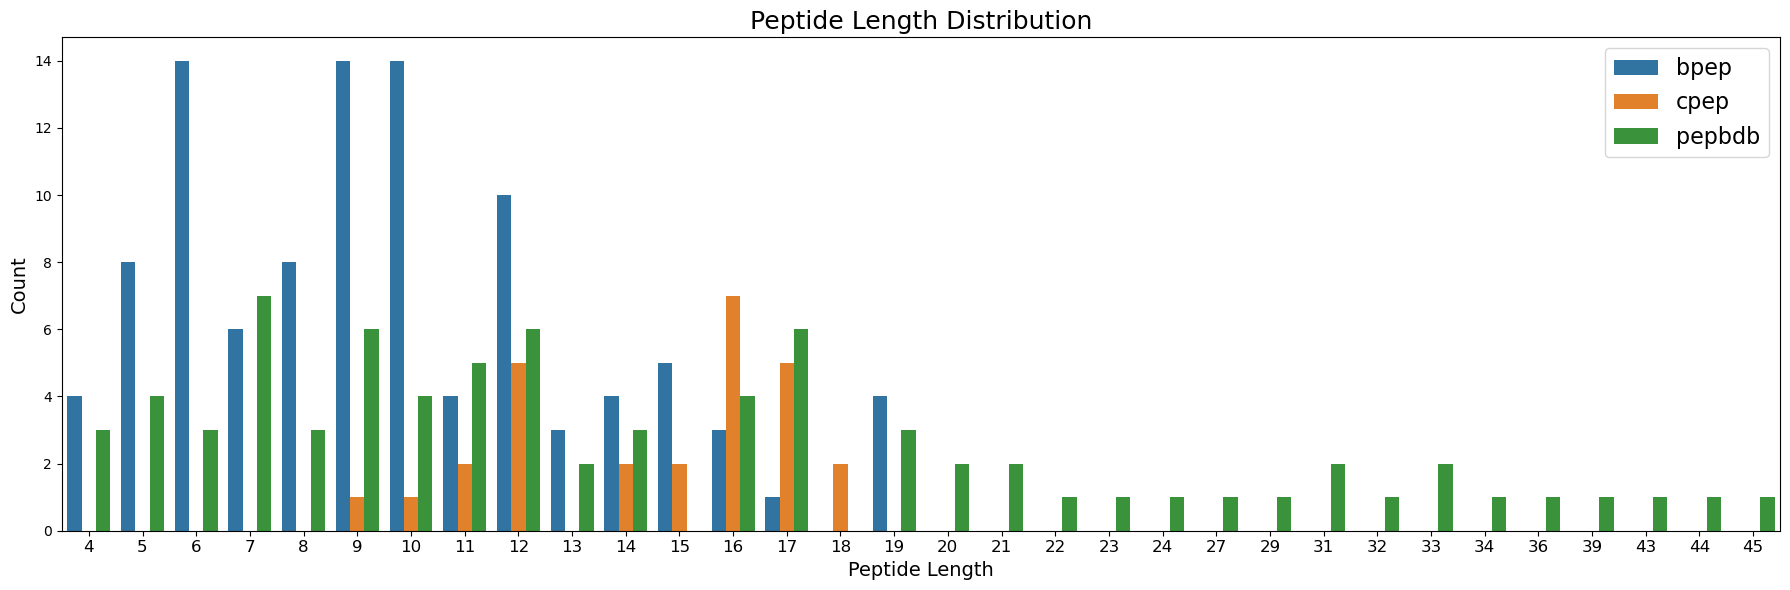

In [12]:
df_meta_bpep['db_name'] = 'bpep'
df_meta_cpep['db_name'] = 'cpep'
df_meta_pepbdb['db_name'] = 'pepbdb'
df_meta = pd.concat([df_meta_bpep, df_meta_cpep, df_meta_pepbdb])

plt.figure(figsize=(18, 6))

sns.countplot(data=df_meta, x='len_pep', hue='db_name', dodge=True)

plt.title('Peptide Length Distribution', fontsize=18)
plt.xlabel('Peptide Length', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.xticks(fontsize=12)

plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig('./metric_stat/peptide_length_distribution.png', dpi=300)
plt.show()

In [13]:
set(df_meta_pepbdb['pdbid']).intersection(set(df_meta_bpep['pdbid']))

set()

In [14]:
set(df_meta_pepbdb['pdbid']).intersection(set(df_meta_cpep['pdbid']))

set()

In [15]:
set(df_meta_bpep['pdbid']).intersection(set(df_meta_cpep['pdbid']))

{'8dvl', '8gqa', '8qfz'}

## Docking Metrics

### Load Data

- keep only successful docking: tag is `np.nan`

- remove all failed docking: `nonstd, incomp, bad`

In [44]:
def rmsd_ca_check(df_metric, threshold=1e-2):
    # 检查 PDBparser 和 TM-align 计算的RMSD-CA-BA 是否一致
    df_metric = df_metric.copy()
    df_metric['check'] = df_metric['rmsd_ca_ba'] - df_metric['rmsd_ca_ba_tmscore']
    df_metric['check'] = df_metric['check'].apply(lambda x: True if abs(x) < threshold or pd.isna(x) else False)
    count = df_metric[df_metric['check']==False].shape[0]
    
    if count > 0:
        print(f"Warning: {count} rows have RMSD-CA BA (PDBparser) and RMSD-CA BA (TM-Align) difference greater than {threshold}")
    else:
        print("Success: All RMSD-CA BA (PDBparser) and RMSD-CA BA (TM-Align) are consistent")

def dock_metric_stat(gen_dir):
    key_col = 'filename_key'

    # gen_info.csv
    df_gen = pd.read_csv(os.path.join(gen_dir, 'gen_info.csv'))

    # 2. metrics files
    file_configs = {
        'rmsd_pdb.csv': ['rmsd'],
        'dockq_pdb.csv': ['dockq', 'irmsd', 'lrmsd'],
        'rmsd_ca_pdb.csv': ['rmsd_ca_ta', 'rmsd_ca_ba'],
        'tmscore_pdb.csv': ['tmscore', 'rmsd_ca_ba']
    }

    def add_filename_key(df, source_name):
        if 'filename' not in df.columns:
            raise KeyError(f"Missing required column 'filename' in {source_name}")

        df = df.copy()
        df[key_col] = df['filename'].astype(str).str.split(r'[-\.]').str[0]

        dup_mask = df[key_col].duplicated(keep=False)
        if dup_mask.any():
            dup_keys = sorted(df.loc[dup_mask, key_col].unique().tolist())
            raise ValueError(
                f"Duplicate filename key(s) found in {source_name}: {dup_keys[:10]}"
            )
        return df

    df_final = add_filename_key(df_gen, 'gen_info.csv')

    for file_name, columns in file_configs.items():
        file_path = os.path.join(gen_dir, file_name)
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Required file missing: {file_name}")

        df_temp = pd.read_csv(file_path)

        # tmscore: rename rmsd_ca_ba to rmsd_ca_ba_tmscore
        if file_name == 'tmscore_pdb.csv':
            df_temp = df_temp.rename(columns={'rmsd_ca_ba': 'rmsd_ca_ba_tmscore'})
            columns = [c if c != 'rmsd_ca_ba' else 'rmsd_ca_ba_tmscore' for c in columns]
        
        required_cols = ['filename'] + columns
        missing_cols = [c for c in required_cols if c not in df_temp.columns]
        if missing_cols:
            raise KeyError(f"Missing required column(s) in {file_name}: {missing_cols}")

        df_temp = add_filename_key(df_temp[required_cols], file_name)

        base_keys = set(df_final[key_col])
        temp_keys = set(df_temp[key_col])
        if base_keys != temp_keys:
            only_base = sorted(list(base_keys - temp_keys))
            only_temp = sorted(list(temp_keys - base_keys))
            raise ValueError(
                f"Filename key mismatch between gen_info.csv and {file_name}. "
                f"Only in gen_info.csv (first 10): {only_base[:10]}, "
                f"only in {file_name} (first 10): {only_temp[:10]}"
            )

        df_final = df_final.merge(
            df_temp[[key_col] + columns],
            on=key_col,
            how='left',
            validate='one_to_one'
        )

    # remove temporary merge key
    df_final = df_final.drop(columns=[key_col])

    # 4. keep only successful dock: tag is np.nan
    ## remove failed dock: nonstd, incomp, bad
    count_all = df_final.shape[0]
    df_final = df_final[df_final['tag'].isna()]
    print('Dropped %d rows with failed dock' % (count_all - df_final.shape[0]))

    # 4. check rmsd_ca_ba consistency: by PDBparser and TM-Align
    rmsd_ca_check(df_final)
    df_final.drop(columns=['rmsd_ca_ba_tmscore'], inplace=True)

    return df_final

In [45]:
gen_dir_bpep = './outputs_test/dock_bpep/base_pxm_20260318_165320'
df_gen_bpep = dock_metric_stat(gen_dir_bpep)

Dropped 48 rows with failed dock
Success: All RMSD-CA BA (PDBparser) and RMSD-CA BA (TM-Align) are consistent


In [46]:
gen_dir_cpep = './outputs_test/dock_cpep/base_pxm_20260318_170001'
df_gen_cpep = dock_metric_stat(gen_dir_cpep)

Dropped 4400 rows with failed dock
Success: All RMSD-CA BA (PDBparser) and RMSD-CA BA (TM-Align) are consistent


In [47]:
gen_dir_pepbdb = './outputs_test/dock_pepbdb/base_pxm_20260317_172745'
df_gen_pepbdb = dock_metric_stat(gen_dir_pepbdb)

Dropped 670 rows with failed dock
Success: All RMSD-CA BA (PDBparser) and RMSD-CA BA (TM-Align) are consistent


In [48]:
df_gen_merge = pd.concat([df_gen_bpep, df_gen_cpep, df_gen_pepbdb], ignore_index=True)

### RMSD / TM-score / DockQ

In [49]:
target_cols = ['rmsd', 'rmsd_ca_ta', 'rmsd_ca_ba', 'dockq', 'tmscore']

In [50]:
# Metrics-1: by mean of each data_id
df_mean = df_gen_merge.groupby('data_id')[target_cols].mean().reset_index()
df_mean['db'] = df_mean['data_id'].str.split('_').str[0]
df_mean.head()

,data_id,rmsd,rmsd_ca_ta,rmsd_ca_ba,dockq,tmscore,db
0,bpep_7prx,10.530774,9.931626,5.354018,0.374211,0.153535,bpep
1,bpep_7qwv,11.211448,10.507821,5.724814,0.311392,0.187576,bpep
2,bpep_7sxf,9.260926,9.461313,2.983720,0.439795,0.305298,bpep
3,bpep_7sxh,9.647865,9.304374,3.060776,0.393295,0.261792,bpep
4,bpep_7tmy,7.866014,7.151036,1.595942,0.550035,0.422412,bpep


In [51]:
# Metrics-2: by max cfd_traj of each data_id
idx = df_gen_merge.groupby('data_id')['cfd_traj'].idxmax() # index with max cfd_traj
df_best_cfd = df_gen_merge.loc[idx, ['data_id', 'db', 'cfd_traj'] + target_cols].reset_index(drop=True)
df_best_cfd.head()

,data_id,db,cfd_traj,rmsd,rmsd_ca_ta,rmsd_ca_ba,dockq,tmscore
0,bpep_7prx,bpep,-0.464588,7.443994,6.298555,4.983485,0.515,0.10333
1,bpep_7qwv,bpep,-0.266619,4.399027,3.204649,3.059636,0.694,0.27589
2,bpep_7sxf,bpep,-0.230480,2.337286,2.546990,2.150659,0.792,0.51968
3,bpep_7sxh,bpep,-0.226187,1.575755,1.310722,1.021160,0.917,0.41369
4,bpep_7tmy,bpep,0.238092,1.004747,0.672509,0.270346,0.976,0.80547


In [52]:
# Metrics-3: by oracle of each data_id
min_cols = ['rmsd', 'rmsd_ca_ta', 'rmsd_ca_ba']
max_cols = ['dockq', 'tmscore']

df_min = df_gen_merge.groupby('data_id')[min_cols].min()
df_max = df_gen_merge.groupby('data_id')[max_cols].max()

df_oracle = pd.concat([df_min, df_max], axis=1).reset_index()
df_oracle['db'] = df_oracle['data_id'].str.split('_').str[0]

df_oracle.head()

,data_id,rmsd,rmsd_ca_ta,rmsd_ca_ba,dockq,tmscore,db
0,bpep_7prx,5.829182,4.656191,3.670846,0.676,0.27065,bpep
1,bpep_7qwv,2.988616,2.263850,2.150560,0.790,0.36926,bpep
2,bpep_7sxf,1.509333,1.434162,1.280068,0.916,0.72789,bpep
3,bpep_7sxh,1.392944,1.056552,0.707488,0.939,0.58068,bpep
4,bpep_7tmy,0.562782,0.452144,0.235948,0.988,0.83213,bpep


In [25]:
def plot_metrics_bar(df_plot, output_path=None):
    
    target_cols = {'rmsd': 'All-atom RMSD', 
               'rmsd_ca_ta': 'Cα RMSD (TA)', 
               'rmsd_ca_ba': 'Cα RMSD (BA)', 
               'dockq': 'DockQ', 
               'tmscore': 'TM-score'}

    sns.set_theme(style="whitegrid")

    fig, axes = plt.subplots(1, 5, figsize=(24, 3))

    for i, col in enumerate(target_cols):
        sns.barplot(
            data=df_plot, 
            x=col, 
            y='db', 
            ax=axes[i], 
            hue='db', 
            errorbar=('ci', 95), 
            capsize=0.1, 
            palette='muted',
            dodge=False
        )
        
        # fontsize
        ## x, y ticklabel
        axes[i].tick_params(axis='both', which='major', labelsize=16)
        ## x, y label
        axes[i].set_xlabel('', fontsize=18)
        axes[i].set_ylabel('', fontsize=18)
        ## subplot title
        axes[i].set_title(f'{target_cols[col]}', fontsize=20, pad=15)

        # xlim
        if col in ['rmsd', 'rmsd_ca_ta', 'rmsd_ca_ba']:
            axes[i].set_xlim(0, 14)
        elif col in ['dockq', 'tmscore']:
            axes[i].set_xlim(0, 1)

        # legend and yticklabels
        if i < 4:
            # 前4个子图：移除自带图例
            legend = axes[i].get_legend()
            if legend is not None:
                legend.remove()
            # 隐藏除了第一个图以外的 y 轴刻度标签
            if i > 0:
                axes[i].set_yticklabels([])
        else:
            # 第5个子图：设置外部图例
            axes[i].legend(title='', loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=14) # title_fontsize=14
            axes[i].set_yticklabels([])

    plt.tight_layout()
    plt.subplots_adjust(right=0.88, top=0.9)
    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

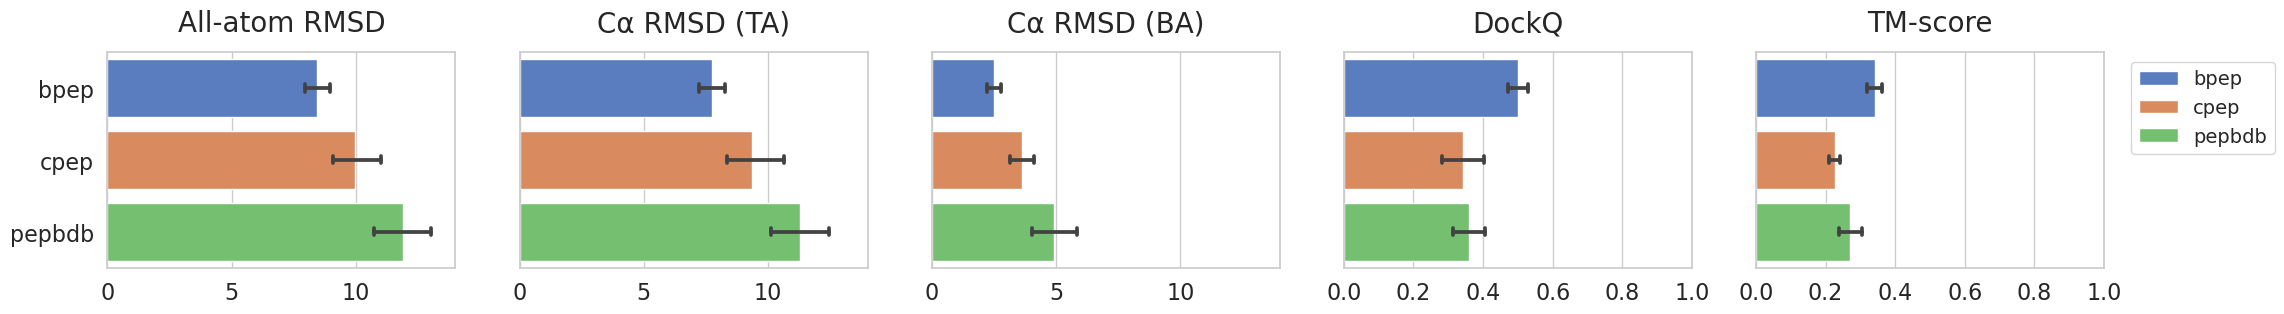

In [26]:
plot_metrics_bar(df_mean, output_path='./metric_stat/pepdock_metrics_bar_mean.png')

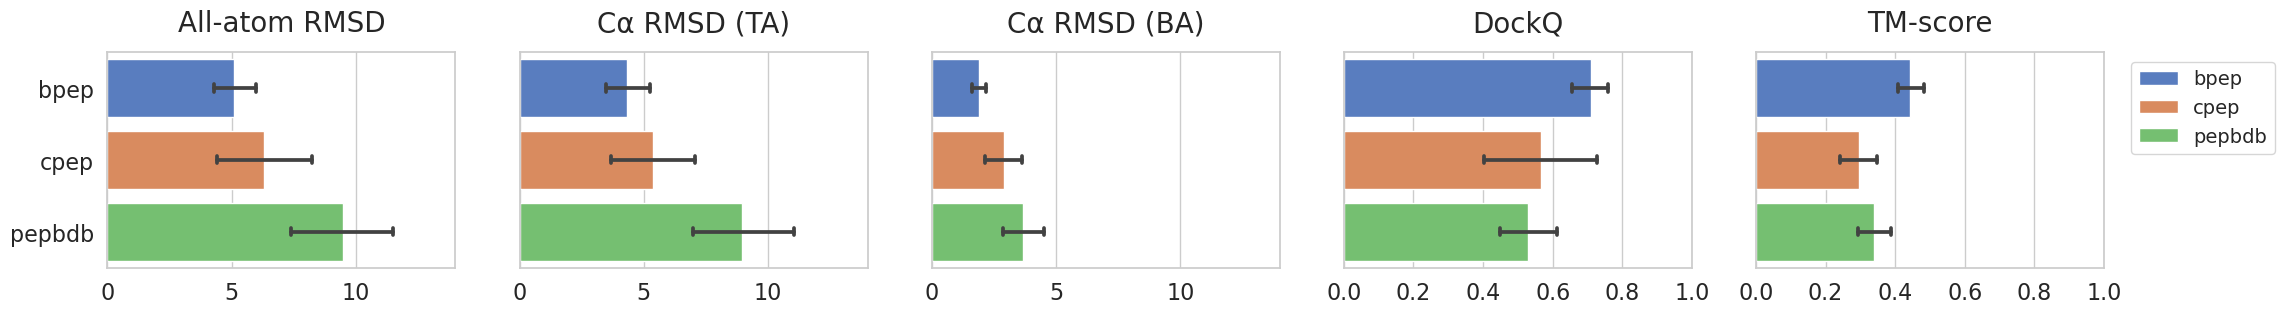

In [27]:
plot_metrics_bar(df_best_cfd, output_path='./metric_stat/pepdock_metrics_bar_best_cfd.png')

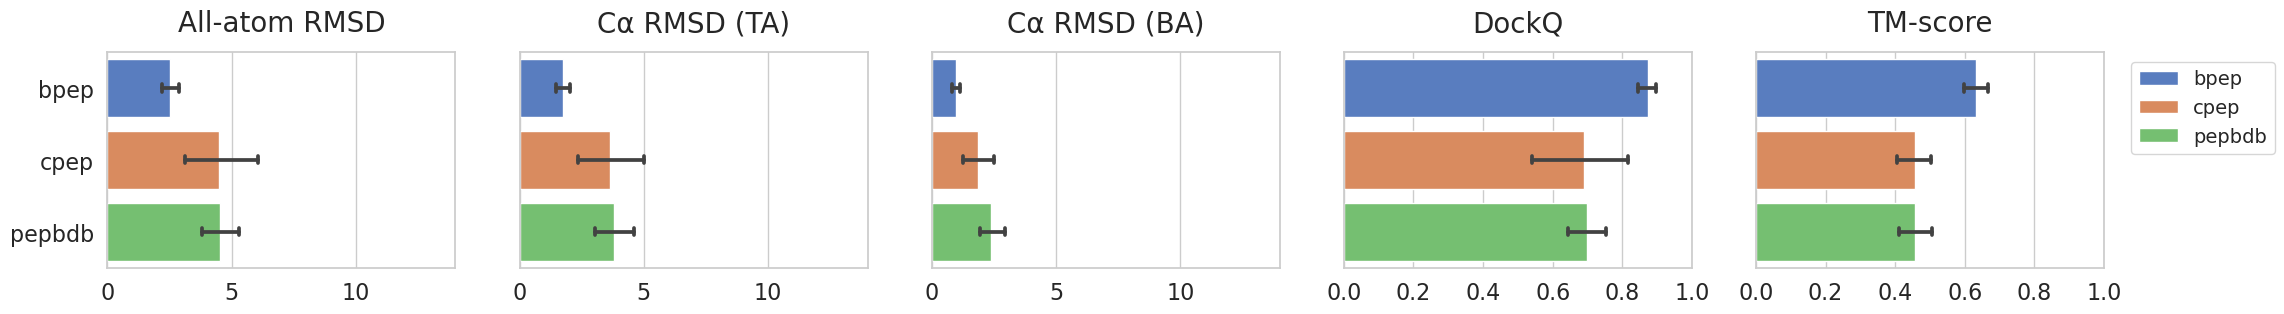

In [ ]:
plot_metrics_bar(df_oracle, output_path='./metric_stat/pepdock_metrics_bar_oracle.png')

### Success Rate

In [29]:
def cal_success_rate(df_metric):
    # 1. label success or not (True/False)
    df_temp = df_metric.assign(is_success=df_metric['rmsd_ca_ta'] < 2)
    
    # 2. 聚合统计：同时计算成功数(sum)和总数(count)
    # 因为 True 在计算时等同于 1，False 等同于 0，所以 sum 结果就是分子
    success_stats = (
        df_temp.groupby('db')['is_success']
        .agg(['sum', 'count'])
        .reset_index()
    )
    
    # 3. 计算百分比
    success_stats['percentage'] = (success_stats['sum'] / success_stats['count']) * 100
    
    # 4. 格式化输出：百分比 (分子/分母)
    # 例如：15.5% (31/200)
    success_stats['success_rate_label'] = success_stats.apply(
        lambda row: f"{int(row['sum'])}/{int(row['count'])} ({row['percentage']:.2f}%)", 
        axis=1
    )
    
    return success_stats

In [ ]:
df_success_mean = cal_success_rate(df_mean)
df_success_best_cfd = cal_success_rate(df_best_cfd)
df_success_oracale = cal_success_rate(df_oracle)

df_success_merge = pd.concat([df_success_mean[['db', 'success_rate_label']], df_success_best_cfd['success_rate_label'], df_success_oracale['success_rate_label']], axis=1)
df_success_merge.columns = ['db', 'mean', 'best_cfd', 'oracle']
df_success_merge.to_csv('./metric_stat/pepdock_success_rate.csv', index=False)
df_success_merge

,db,mean,best_cfd,oracle
0,bpep,2/102 (1.96%),40/102 (39.22%),69/102 (67.65%)
1,cpep,0/7 (0.00%),1/7 (14.29%),1/7 (14.29%)
2,pepbdb,0/66 (0.00%),13/66 (19.70%),18/66 (27.27%)


## Invserse-Folding Metrics

### Load Data

In [32]:
import ast

def pepinv_metric_stat(gen_dir):
    df_sc = pd.read_csv(os.path.join(gen_dir, 'sc_metrics.csv'))
    # keep only successful sample: tag is np.nan
    df_sc = df_sc[df_sc['succ']]
    df_sc['sc_rmsd_list'] = df_sc['sc_rmsd_list'].apply(ast.literal_eval)
    return df_sc

In [33]:
gen_dir_bpep = './outputs_test/pepinv_bpep/base_pxm_20260319_115259'
df_scrmsd_bpep = pepinv_metric_stat(gen_dir_bpep)

In [34]:
gen_dir_cpep = './outputs_test/pepinv_cpep/base_pxm_20260320_223246'
df_scrmsd_cpep = pepinv_metric_stat(gen_dir_cpep)

In [35]:
gen_dir_pepbdb = './outputs_test/pepinv_pepbdb/base_pxm_20260319_163803'
df_scrmsd_pepbdb = pepinv_metric_stat(gen_dir_pepbdb)

### sc-RMSD

In [36]:
df_scrmsd_cpep.groupby('data_id')['aa_recovery_rate'].max().reset_index()

,data_id,aa_recovery_rate
0,cpep_7y8d,NaN
1,cpep_7y90,NaN
2,cpep_7ya5,NaN
3,cpep_7zrt,NaN
4,cpep_8dvl,0.500000
5,cpep_8ei0,NaN
6,cpep_8ei2,0.266667
7,cpep_8ei4,0.312500
8,cpep_8ei8,0.411765
9,cpep_8f4b,NaN


In [37]:
def plot_sc_rmsd_hist(df_scrmsd, db_name, output_path=None):
    
    sc_rmsd_list = []
    for value in df_scrmsd['sc_rmsd_list']:
        sc_rmsd_list += value
    
    # Median
    sc_median = np.median(sc_rmsd_list)

    plt.figure(figsize=(4, 3))

    ax = sns.histplot(sc_rmsd_list, stat='percent', bins=24, color='#81abad', edgecolor='white')

    ax.axvline(sc_median, color='red', linestyle='--', linewidth=2, label='Median')
    y_max = ax.get_ylim()[1]
    ax.text(sc_median * 1.5, y_max * 0.9, f'Median: {sc_median:.3f}', 
            color='red', fontsize=12, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

    plt.xlabel('Side-chain RMSD of\nrecovered residues ($\AA$)', fontsize=14)
    plt.ylabel('Percentage (%)', fontsize=14)
    plt.title(f'{db_name}', fontsize=16)

    plt.ylim(0, 50)

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

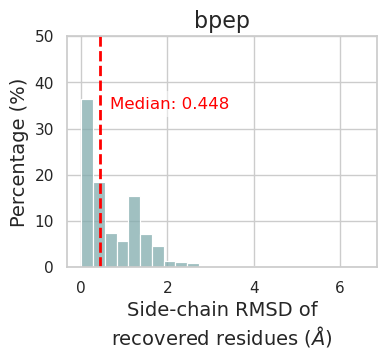

In [38]:
plot_sc_rmsd_hist(df_scrmsd_bpep, db_name='bpep', output_path='./metric_stat/pepinv_sc_rmsd_hist_bpep.png')

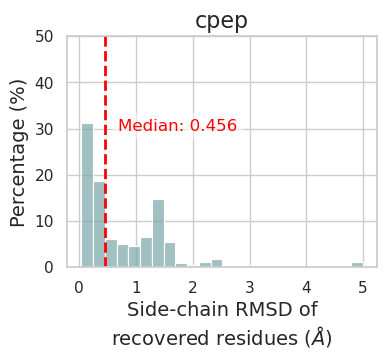

In [39]:
plot_sc_rmsd_hist(df_scrmsd_cpep, db_name='cpep', output_path='./metric_stat/pepinv_sc_rmsd_hist_cpep.png')

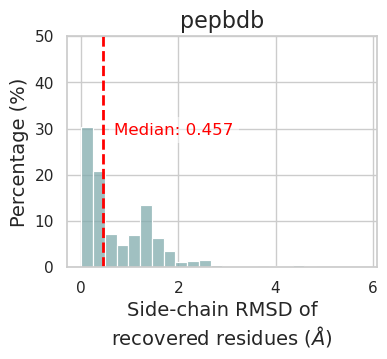

In [40]:
plot_sc_rmsd_hist(df_scrmsd_pepbdb, db_name='pepbdb', output_path='./metric_stat/pepinv_sc_rmsd_hist_pepbdb.png')

### sequence recovery rate

In [41]:
def plot_seq_recovery_hist(df_metric, db_name, output_path=None):
    
    
    
    df_metric_max = df_metric.groupby('data_id')['aa_recovery_rate'].max().reset_index()
    seq_recovery_list = df_metric_max['aa_recovery_rate'].dropna().tolist()
    seq_recovery_list = [value * 100 for value in seq_recovery_list]

    # Median
    sc_median = np.median(seq_recovery_list)

    plt.figure(figsize=(4, 3))

    ax = sns.histplot(seq_recovery_list, stat='percent', bins=24, color='#81abad', edgecolor='white')

    ax.axvline(sc_median, color='red', linestyle='--', linewidth=2, label='Median')
    y_max = ax.get_ylim()[1]
    ax.text(sc_median * 0.1, y_max * 0.9, f'Median: {sc_median:.3f}', 
            color='red', fontsize=12, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

    plt.xlabel('Sequence recovery rate (%)', fontsize=14)
    plt.ylabel('Percentage (%)', fontsize=14)
    plt.title(f'{db_name}', fontsize=16)

    plt.ylim(0, 50)

    plt.xlim(0, 100)

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

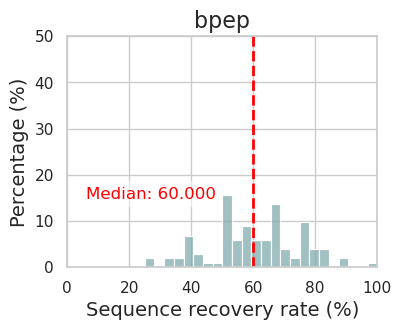

In [42]:
plot_seq_recovery_hist(df_scrmsd_bpep, db_name='bpep', output_path='./metric_stat/pepinv_seq_recovery_rate_bpep.png')

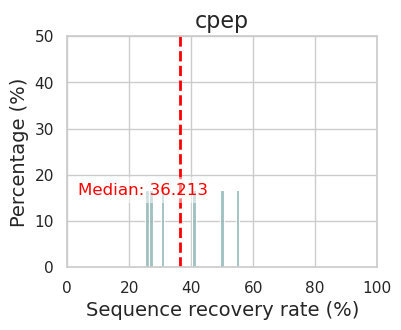

In [43]:
plot_seq_recovery_hist(df_scrmsd_cpep, db_name='cpep', output_path='./metric_stat/pepinv_seq_recovery_rate_cpep.png')

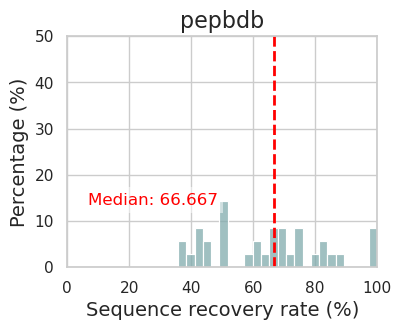

In [44]:
plot_seq_recovery_hist(df_scrmsd_pepbdb, db_name='pepbdb', output_path='./metric_stat/pepinv_seq_recovery_rate_pepbdb.png')

In [45]:
df_scrmsd_bpep

,data_id,non_std_data,filename,succ,gt_seq,aaseq,sc_rmsd_list,aa_recovery_rate
0,bpep_7prx,False,89.pdb,True,PPQEAEEPSLLKKLLLAPA,GAATGAYPETIERLLQESA,"[0.24258047, 1.8164213, 1.2540709, 0.24729775]",0.210526
1,bpep_7prx,False,191.pdb,True,PPQEAEEPSLLKKLLLAPA,GSAGGSKATLLEYILDEAD,"[1.2618443, 0.31583118, 0.16539428]",0.157895
2,bpep_7prx,False,293.pdb,True,PPQEAEEPSLLKKLLLAPA,SAPGGPKEHLIEYLMDRED,"[1.245752, 1.7826893]",0.105263
4,bpep_7prx,False,497.pdb,True,PPQEAEEPSLLKKLLLAPA,AAAGADEDFHLFRLLKFAT,"[0.1476731, 3.448183, 0.44652486, 1.791567, 0....",0.263158
5,bpep_7prx,False,599.pdb,True,PPQEAEEPSLLKKLLLAPA,AAAAGIHTKQLLELLERSD,"[0.5183021, 0.53169966, 0.16758081]",0.157895
...,...,...,...,...,...,...,...,...
19684,bpep_9f42,False,19874.pdb,True,RVFFMDDVE,FNFFDADVE,"[1.4393222, 4.0087004, 1.0326687, 1.7336245, 2...",0.555556
19685,bpep_9f42,False,19976.pdb,True,RVFFMDDVE,SIEDEDDVD,"[1.1298826, 1.271787, 1.7809938]",0.333333
19686,bpep_9f42,False,20078.pdb,True,RVFFMDDVE,QVFFLDSVD,"[1.7543534, 1.4650376, 3.9317245, 1.0939102, 0...",0.555556
19687,bpep_9f42,False,20180.pdb,True,RVFFMDDVE,FLYELDDVE,"[0.17173384, 0.5181708, 1.7182518, 2.43525]",0.444444


## Peptide Design Metrics

### Load Data

- keep only successful docking: tag is `np.nan`

- remove all failed docking: `nonstd, incomp, bad`

In [2]:
def pepdesign_metric_stat(gen_dir):
    key_col = 'filename_key'

    # gen_info.csv
    df_gen = pd.read_csv(os.path.join(gen_dir, 'gen_info.csv'))

    # 2. metrics files
    file_configs = {
        # 'rmsd_pdb.csv': ['rmsd'],
        # 'dockq_pdb.csv': ['dockq', 'irmsd', 'lrmsd'],
        'rmsd_ca_pdb.csv': ['rmsd_ca_ta', 'rmsd_ca_ba'],
        'tmscore_pdb.csv': ['tmscore', 'rmsd_ca_ba'],
        'metrics.csv': ['seq_iden', 'rmsd', 'ss', 'ss_gt', 'phi', 'psi'],
        'rama_stat.csv': ['total_angle_numbers', 'total_accept', 'accept_rate', 'total_favoured', 'favoured_rate'],
        'rama_stat_gt.csv': ['total_angle_numbers', 'total_accept', 'accept_rate', 'total_favoured', 'favoured_rate']
    }

    def add_filename_key(df, source_name):
        if 'filename' not in df.columns:
            raise KeyError(f"Missing required column 'filename' in {source_name}")

        df = df.copy()
        df[key_col] = df['filename'].astype(str).str.split(r'[-_\.]').str[0] # '_' for _gt.pdb in rama_stat_gt.csv / vina_score_gt.csv

        dup_mask = df[key_col].duplicated(keep=False)
        if dup_mask.any():
            dup_keys = sorted(df.loc[dup_mask, key_col].unique().tolist())
            raise ValueError(
                f"Duplicate filename key(s) found in {source_name}: {dup_keys[:10]}"
            )
        return df
    
    # total: gen_info.csv
    df_final = add_filename_key(df_gen, 'gen_info.csv')

    # metrics: 
    for file_name, columns in file_configs.items():
        file_path = os.path.join(gen_dir, file_name)
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Required file missing: {file_name}")

        df_temp = pd.read_csv(file_path)

        # tmscore: rename rmsd_ca_ba to rmsd_ca_ba_tmscore
        if file_name == 'tmscore_pdb.csv':
            df_temp = df_temp.rename(columns={'rmsd_ca_ba': 'rmsd_ca_ba_tmscore'})
            columns = ['tmscore', 'rmsd_ca_ba_tmscore']
        elif file_name == 'metrics.csv':
            df_temp = df_temp.rename(columns={'rmsd': 'rmsd_bb'})
            columns = ['seq_iden', 'rmsd_bb', 'ss', 'ss_gt', 'phi', 'psi']
        elif file_name == 'rama_stat_gt.csv':
            rename_dict = {}
            for col in file_configs['rama_stat_gt.csv']:
                rename_dict[col] = f'{col}_gt'
            df_temp = df_temp.rename(columns=rename_dict)
            columns = list(rename_dict.values())
        # elif file_name == 'vina_score_gt.csv':
        #     df_temp = df_temp.rename(columns={'vina_score': 'vina_score_gt'})
        #     columns = ['vina_score_gt']

        required_cols = ['filename'] + columns
        missing_cols = [c for c in required_cols if c not in df_temp.columns]
        if missing_cols:
            raise KeyError(f"Missing required column(s) in {file_name}: {missing_cols}")

        df_temp = add_filename_key(df_temp[required_cols], file_name)

        # check filename key
        base_keys = set(df_final[key_col])
        temp_keys = set(df_temp[key_col])
        if base_keys != temp_keys:
            only_base = sorted(list(base_keys - temp_keys))
            only_temp = sorted(list(temp_keys - base_keys))
            raise ValueError(
                f"Filename key mismatch between gen_info.csv and {file_name}. "
                f"Only in gen_info.csv (first 10): {only_base[:10]}, "
                f"only in {file_name} (first 10): {only_temp[:10]}"
            )

        # merge
        df_final = df_final.merge(
            df_temp[[key_col] + columns],
            on=key_col,
            how='left',
            validate='one_to_one' # check if the merge is one-to-one
        )

    # remove temporary merge key
    df_final = df_final.drop(columns=[key_col])

    # 4. keep all rows: used for ground truth
    df_final_full = df_final.copy()

    # 5. keep only successful pepdesign: tag is np.nan
    ## remove failed pepdesign: nonstd, incomp, bad
    count_all = df_final.shape[0]
    df_final = df_final[df_final['tag'].isna()]
    print('Dropped %d rows with failed pepdesign' % (count_all - df_final.shape[0]))

    # 6. check rmsd_ca_ba consistency: by PDBparser and TM-Aligns
    # rmsd_ca_check(df_final)
    # df_final.drop(columns=['rmsd_ca_ba_tmscore'], inplace=True)

    return df_final, df_final_full

In [3]:
# remove cpep with X_ratio > 20%
df_cpep_meta = pd.read_csv('./data_train/cpep/dfs/meta_uni.csv')
df_cpep_meta['X_ratio'] = df_cpep_meta['pep_seq'].map(lambda x: x.count('X') / len(x))
df_cpep_meta = df_cpep_meta[df_cpep_meta['X_ratio']<=0.2].copy()
cpep_keep_ids = df_cpep_meta['data_id'].tolist()
len(cpep_keep_ids)

16

In [4]:
gen_dir_bpep = './outputs_test/pepdesign_bpep/base_pxm_20260325_130808'
df_gen_bpep, df_gen_bpep_full = pepdesign_metric_stat(gen_dir_bpep)

Dropped 7033 rows with failed pepdesign


In [5]:
gen_dir_cpep = './outputs_test/pepdesign_cpep/base_pxm_20260328_141105'
df_gen_cpep, df_gen_cpep_full = pepdesign_metric_stat(gen_dir_cpep)

Dropped 4364 rows with failed pepdesign


In [6]:
# df_gen_cpep = df_gen_cpep[df_gen_cpep['data_id'].isin(cpep_keep_ids)].copy()
# df_gen_cpep_full = df_gen_cpep_full[df_gen_cpep_full['data_id'].isin(cpep_keep_ids)].copy()

In [7]:
gen_dir_pepbdb = './outputs_test/pepdesign_pepbdb/base_pxm_20260325_130506'
df_gen_pepbdb, df_gen_pepbdb_full = pepdesign_metric_stat(gen_dir_pepbdb)

Dropped 2217 rows with failed pepdesign


In [8]:
gen_dir_pepmerge = './outputs_test/pepdesign_pepmerge/base_pxm_20260407_132739'
df_gen_pepmers, df_gen_pepmers_full = pepdesign_metric_stat(gen_dir_pepmerge)

Dropped 14643 rows with failed pepdesign


In [9]:
df_gen_merge = pd.concat([df_gen_bpep, df_gen_cpep, df_gen_pepbdb, df_gen_pepmers], ignore_index=True)
df_gen_merge_full = pd.concat([df_gen_bpep_full, df_gen_cpep_full, df_gen_pepbdb_full, df_gen_pepmers_full], ignore_index=True)

### RMSD / TM-score / DockQ

In [10]:
target_cols = ['rmsd_bb', 'rmsd_ca_ta', 'rmsd_ca_ba', 'tmscore']

In [11]:
# Metrics-1: by mean of each data_id
df_mean = df_gen_merge.groupby('data_id')[target_cols].mean().reset_index()
df_mean['db'] = df_mean['data_id'].str.split('_').str[0]
df_mean.head()

,data_id,rmsd_bb,rmsd_ca_ta,rmsd_ca_ba,tmscore,db
0,bpep_7prx,16.371824,16.488504,6.801121,0.159109,bpep
1,bpep_7qwv,13.387682,13.391817,6.171336,0.169774,bpep
2,bpep_7sxf,10.131577,10.108701,5.279954,0.203777,bpep
3,bpep_7sxh,10.065151,9.975478,4.895910,0.215915,bpep
4,bpep_7tmy,8.002096,7.935847,1.824067,0.403169,bpep


In [12]:
# Metrics-2: by max cfd_traj of each data_id
idx = df_gen_merge.groupby('data_id')['cfd_traj'].idxmax() # index with max cfd_traj
df_best_cfd = df_gen_merge.loc[idx, ['data_id', 'db', 'cfd_traj'] + target_cols].reset_index(drop=True)
df_best_cfd.head()

,data_id,db,cfd_traj,rmsd_bb,rmsd_ca_ta,rmsd_ca_ba,tmscore
0,bpep_7prx,bpep,0.544833,11.039659,11.246176,7.040817,0.12882
1,bpep_7qwv,bpep,0.621439,9.761112,9.719139,8.743685,0.05169
2,bpep_7sxf,bpep,0.581003,6.983666,7.346817,3.589381,0.19843
3,bpep_7sxh,bpep,0.551158,4.389820,4.209871,2.396008,0.28371
4,bpep_7tmy,bpep,0.717753,13.208302,12.960082,2.153285,0.40643


In [13]:
# Metrics-3: by oracle of each data_id
min_cols = ['rmsd_bb', 'rmsd_ca_ta', 'rmsd_ca_ba']
max_cols = ['tmscore'] # 'rama_accept_rate', 'rama_favoured_rate'

df_min = df_gen_merge.groupby('data_id')[min_cols].min()
df_max = df_gen_merge.groupby('data_id')[max_cols].max()

df_oracle = pd.concat([df_min, df_max], axis=1).reset_index()
df_oracle['db'] = df_oracle['data_id'].str.split('_').str[0]

df_oracle.head()

,data_id,rmsd_bb,rmsd_ca_ta,rmsd_ca_ba,tmscore,db
0,bpep_7prx,6.956961,6.959837,3.701233,0.34914,bpep
1,bpep_7qwv,3.490307,3.624128,2.946580,0.29736,bpep
2,bpep_7sxf,3.373827,3.597623,2.691976,0.41772,bpep
3,bpep_7sxh,3.082611,2.980831,0.929140,0.49405,bpep
4,bpep_7tmy,0.692105,0.668387,0.350481,0.70501,bpep


In [15]:
def plot_metrics_bar(df_plot, output_path=None):
    
    target_cols = {'rmsd_bb': 'Backbone RMSD', 
               'rmsd_ca_ta': 'Cα RMSD (TA)', 
               'rmsd_ca_ba': 'Cα RMSD (BA)', 
               # 'dockq': 'DockQ', 
               'tmscore': 'TM-score',
               # 'rama_accept_rate': 'Accept Rate',
               # 'rama_favoured_rate': 'Favoured Rate'
               }

    sns.set_theme(style="whitegrid")

    fig_num = len(target_cols)
    fig, axes = plt.subplots(1, fig_num, figsize=(18, 4))

    for i, col in enumerate(target_cols):
        sns.barplot(
            data=df_plot, 
            x=col, 
            y='db', 
            ax=axes[i], 
            hue='db', 
            errorbar=('ci', 95), 
            capsize=0.1, 
            palette='muted',
            dodge=False
        )
        
        # fontsize
        ## x, y ticklabel
        axes[i].tick_params(axis='both', which='major', labelsize=16)
        ## x, y label
        axes[i].set_xlabel('', fontsize=18)
        axes[i].set_ylabel('', fontsize=18)
        ## subplot title
        axes[i].set_title(f'{target_cols[col]}', fontsize=20, pad=15)

        # xlim
        if col in ['rmsd_bb', 'rmsd_ca_ta', 'rmsd_ca_ba']:
            axes[i].set_xlim(0, 14)
        elif col in ['dockq', 'tmscore', 'rama_accept_rate', 'rama_favoured_rate']:
            axes[i].set_xlim(0, 1)

        # legend and yticklabels
        if i < fig_num - 1:
            # 前3个子图：移除自带图例
            legend = axes[i].get_legend()
            if legend is not None:
                legend.remove()
            # 隐藏除了第一个图以外的 y 轴刻度标签
            if i > 0:
                axes[i].set_yticklabels([])
        else:
            # 最后一个子图：设置外部图例
            axes[i].legend(title='', loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=14) # title_fontsize=14
            axes[i].set_yticklabels([])

    plt.tight_layout()
    plt.subplots_adjust(right=0.88, top=0.9)
    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

/home/yangziqing/miniconda3/envs/pxm/lib/python3.8/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))


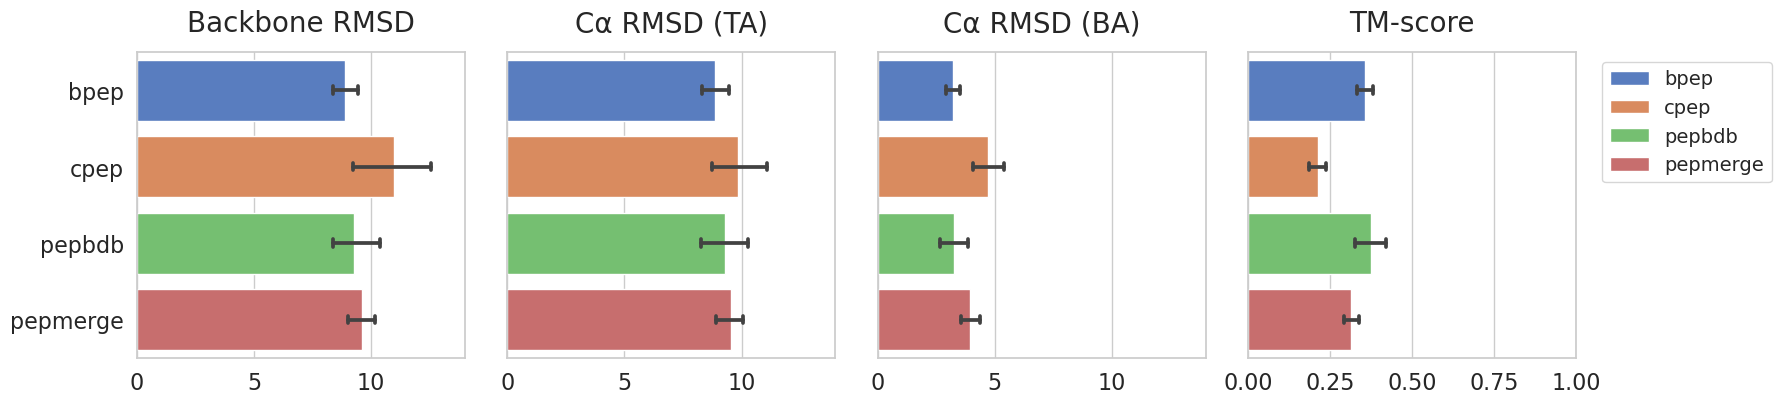

In [16]:
plot_metrics_bar(df_mean, output_path='./metric_stat/pepdesign_metrics_bar_mean.png')

/home/yangziqing/miniconda3/envs/pxm/lib/python3.8/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))


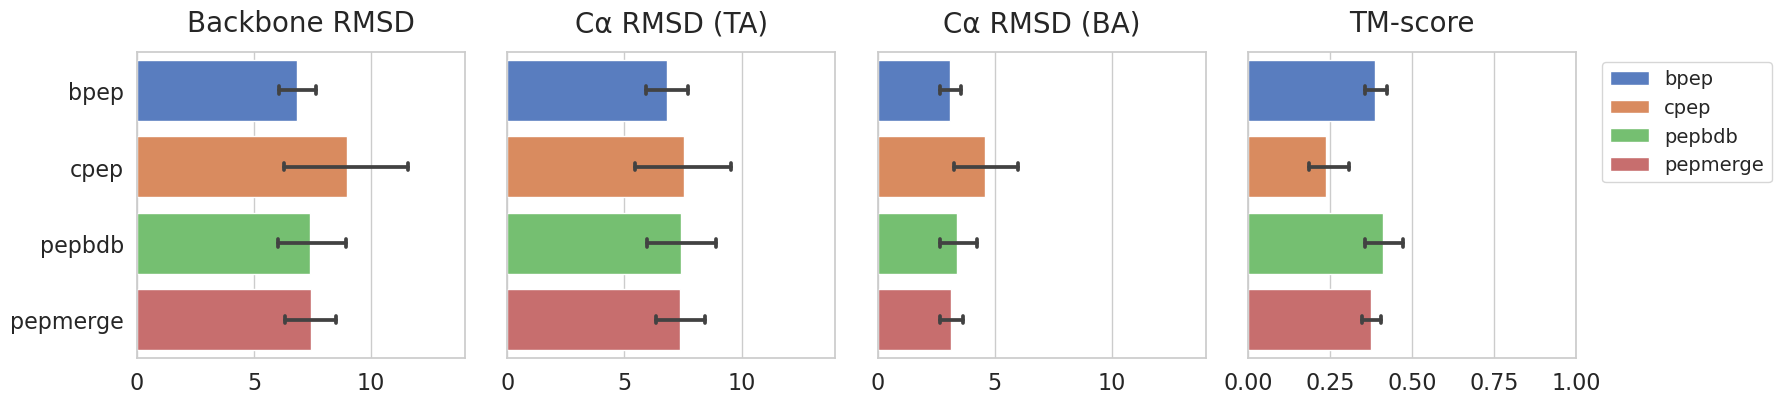

In [17]:
plot_metrics_bar(df_best_cfd, output_path='./metric_stat/pepdesign_metrics_bar_best_cfd.png')

/home/yangziqing/miniconda3/envs/pxm/lib/python3.8/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))


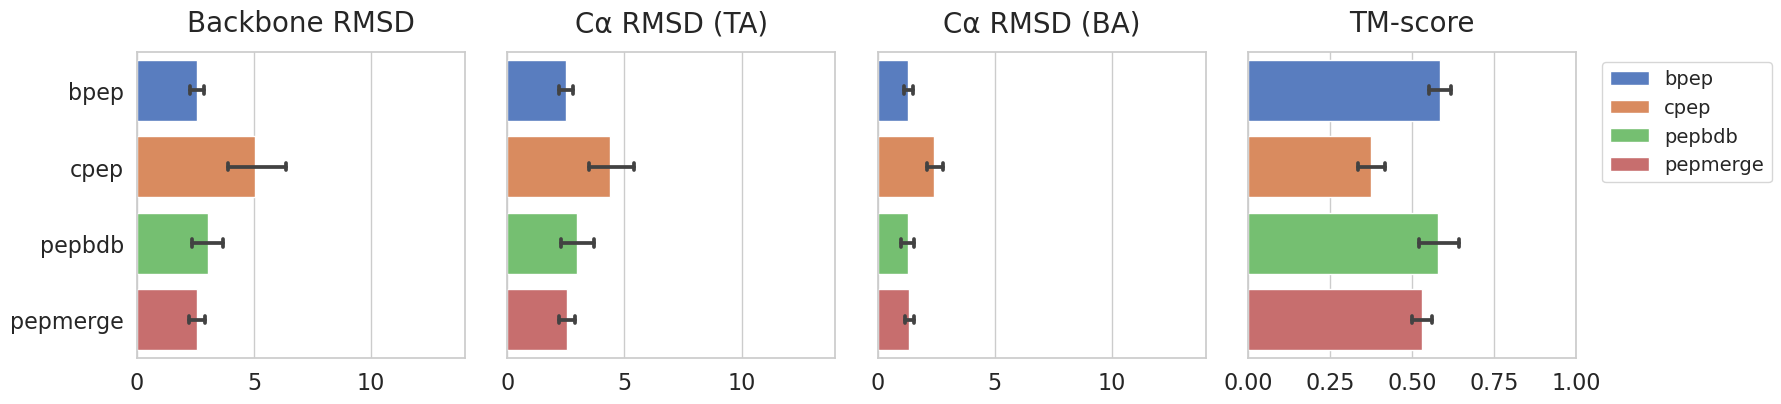

In [18]:
plot_metrics_bar(df_oracle, output_path='./metric_stat/pepdesign_metrics_bar_oracle.png')

### Success Rate

In [19]:
def cal_success_rate(df_metric):
    # 1. label success or not (True/False)
    df_temp = df_metric.assign(is_success=df_metric['rmsd_ca_ta'] < 2)
    
    # 2. 聚合统计：同时计算成功数(sum)和总数(count)
    # 因为 True 在计算时等同于 1，False 等同于 0，所以 sum 结果就是分子
    success_stats = (
        df_temp.groupby('db')['is_success']
        .agg(['sum', 'count'])
        .reset_index()
    )
    
    # 3. 计算百分比
    success_stats['percentage'] = (success_stats['sum'] / success_stats['count']) * 100
    
    # 4. 格式化输出：百分比 (分子/分母)
    # 例如：15.5% (31/200)
    success_stats['success_rate_label'] = success_stats.apply(
        lambda row: f"{int(row['sum'])}/{int(row['count'])} ({row['percentage']:.2f}%)", 
        axis=1
    )
    
    return success_stats

In [20]:
df_success_mean = cal_success_rate(df_mean)
df_success_best_cfd = cal_success_rate(df_best_cfd)
df_success_oracale = cal_success_rate(df_oracle)

df_success_merge = pd.concat([df_success_mean[['db', 'success_rate_label']], df_success_best_cfd['success_rate_label'], df_success_oracale['success_rate_label']], axis=1)
df_success_merge.columns = ['db', 'mean', 'best_cfd', 'oracle']
df_success_merge.to_csv('./metric_stat/pepdesign_success_rate.csv', index=False)
df_success_merge

,db,mean,best_cfd,oracle
0,bpep,0/102 (0.00%),18/102 (17.65%),47/102 (46.08%)
1,cpep,0/13 (0.00%),1/13 (7.69%),1/13 (7.69%)
2,pepbdb,0/35 (0.00%),4/35 (11.43%),14/35 (40.00%)
3,pepmerge,0/127 (0.00%),25/127 (19.69%),55/127 (43.31%)


### Sequence recovery rate

In [21]:
def plot_seq_recovery_hist(df_metric, db_name, output_path=None):
    
    
    
    df_metric_max = df_metric.groupby('data_id')['seq_iden'].max().reset_index()
    seq_recovery_list = df_metric_max['seq_iden'].dropna().tolist()
    seq_recovery_list = [value * 100 for value in seq_recovery_list]

    # Median
    sc_median = np.median(seq_recovery_list)

    plt.figure(figsize=(4, 3))

    ax = sns.histplot(seq_recovery_list, stat='percent', bins=24, color='#81abad', edgecolor='white')

    ax.axvline(sc_median, color='red', linestyle='--', linewidth=2, label='Median')
    y_max = ax.get_ylim()[1]
    ax.text(sc_median * 0.1, y_max * 1.2, f'Median: {sc_median:.3f}', 
            color='red', fontsize=12, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

    plt.xlabel('Sequence recovery rate (%)', fontsize=14)
    plt.ylabel('Percentage (%)', fontsize=14)
    plt.title(f'{db_name}', fontsize=16)

    plt.ylim(0, 50)

    plt.xlim(0, 100)

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

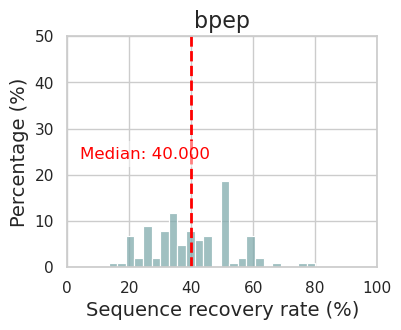

In [20]:
plot_seq_recovery_hist(df_gen_merge[df_gen_merge['db']=='bpep'].copy(), db_name='bpep', output_path='./metric_stat/pepdesign_seq_recovery_rate_bpep.png')

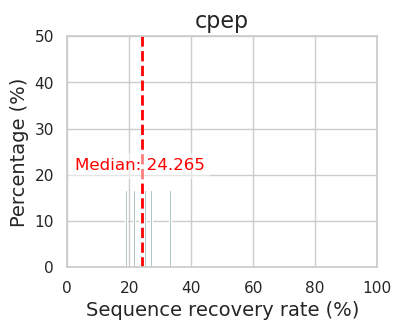

In [21]:
plot_seq_recovery_hist(df_gen_merge[df_gen_merge['db']=='cpep'].copy(), db_name='cpep', output_path='./metric_stat/pepdesign_seq_recovery_rate_cpep.png')

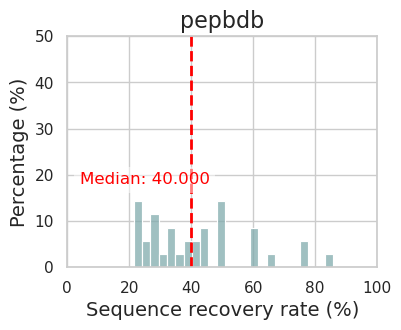

In [22]:
plot_seq_recovery_hist(df_gen_merge[df_gen_merge['db']=='pepbdb'].copy(), db_name='pepbdb', output_path='./metric_stat/pepdesign_seq_recovery_rate_pepbdb.png')

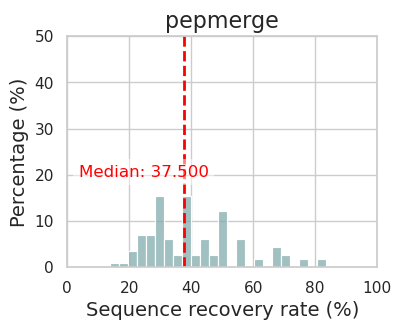

In [22]:
plot_seq_recovery_hist(df_gen_merge[df_gen_merge['db']=='pepmerge'].copy(), db_name='pepmerge', output_path='./metric_stat/pepdesign_seq_recovery_rate_pepmerge.png')

### Backbone RMSD

In [14]:
thresholds = [1, 2, 3, 4, 5]

In [15]:
def bb_rmsd_stat(df_metric, thresholds):
    """
    Calculate the percentage of rmsd_bb less than each threshold for each database.
    """
    
    df_temp = df_metric.copy()
    for t in thresholds:
        df_temp[f'lt_{t}'] = (df_temp['rmsd_bb'] < t)
    
    lt_cols = [f'lt_{t}' for t in thresholds]
    df_threshold_stats = df_temp.groupby('db')[lt_cols].mean() * 100
    
    df_threshold_stats.columns = [f'rmsd_bb_lt_{t}' for t in thresholds]
    return df_threshold_stats.reset_index()

In [16]:
df_mean_bb_rmsd = bb_rmsd_stat(df_mean, thresholds)
df_best_cfd_bb_rmsd = bb_rmsd_stat(df_best_cfd, thresholds)
df_oracle_bb_rmsd = bb_rmsd_stat(df_oracle, thresholds)

In [17]:
output_path = './metric_stat/pepdesign_bb_rmsd.png'

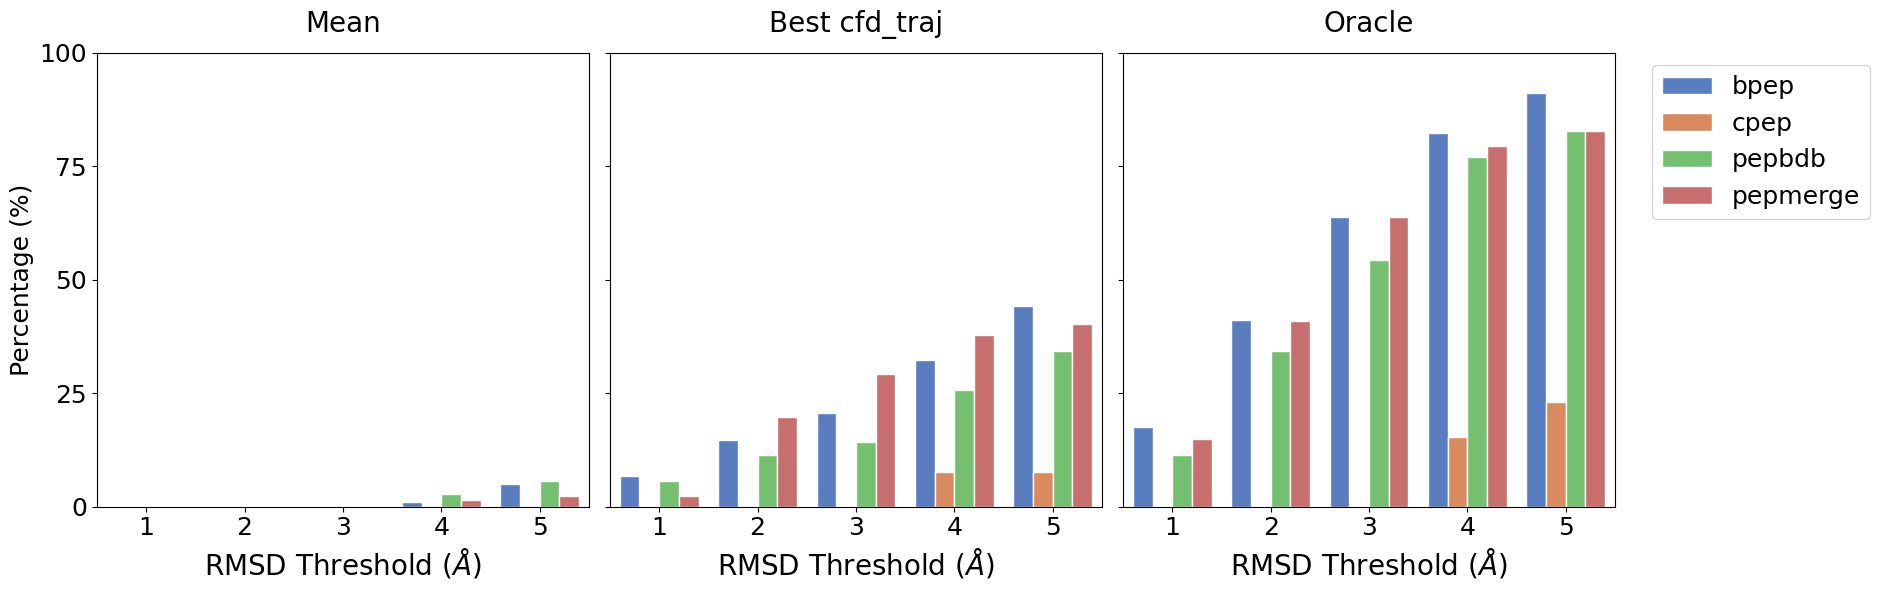

In [ ]:
dfs = {
    'Mean': df_mean_bb_rmsd, 
    'Best cfd_traj': df_best_cfd_bb_rmsd, 
    'Oracle': df_oracle_bb_rmsd
}

value_vars = [f'rmsd_bb_lt_{t}' for t in thresholds]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# 在前面运行了sns.set_theme(style="whitegrid")之后, 需要restart才能绘制空白背景的图
for i, (title, df_target) in enumerate(dfs.items()):
    # --- 数据处理 ---
    df_long = pd.melt(
        df_target, 
        id_vars=['db'], 
        value_vars=value_vars, 
        var_name='threshold_raw', 
        value_name='percentage'
    )
    df_long['threshold'] = df_long['threshold_raw'].str.extract('(\d+)').astype(int)

    # --- 绘图 ---
    ax = axes[i]
    sns.barplot(
        data=df_long, 
        x='threshold', 
        y='percentage', 
        hue='db', 
        ax=ax,
        palette='muted', 
        edgecolor='white'
    )

    # --- 细节设置 ---
    ax.set_title(title, fontsize=20, pad=15)
    ax.set_xlabel('RMSD Threshold ($\AA$)', fontsize=20)
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.tick_params(axis='both', which='major', labelsize=18, colors='black')
    
    # 只有第一个图显示 Y 轴标签
    if i == 0:
        ax.set_ylabel('Percentage (%)', fontsize=18)
    else:
        ax.set_ylabel('')

    
    if i < 2:
        # 前两个图去掉图例
        if ax.get_legend():
            ax.get_legend().remove()
    else:
        # 最后一个图保留图例并放到右侧外
        ax.legend(title='', loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=18)

plt.tight_layout()
plt.subplots_adjust(right=0.9)
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

### Secondary structure

In [19]:
def get_ss_distribution(df, col_name):
    results = []
    for db_name, group in df.groupby('db'):
        # 将该组所有序列连成一个长字符串，并转为 List（每个字符是一个元素）
        all_chars = list("".join(group[col_name].astype(str)))
        
        counts = pd.Series(all_chars).value_counts()
        
        counts['db'] = db_name
        results.append(counts)

    return pd.DataFrame(results).set_index('db').fillna(0).astype(int)


def map_ss_to_categories(df_counts):
    
    dssp_mapping = {
        'Helix (H, G, I)': ['H', 'G', 'I'],
        'Turn (T)': ['T'],
        'Bend (S)': ['S'],
        'Coil (-)': ['-'],
        'Others (E, B)': ['E', 'B']
    }
    
    df_mapped = pd.DataFrame(index=df_counts.index)
    
    for category, chars in dssp_mapping.items():
        existing_chars = [c for c in chars if c in df_counts.columns]
        if existing_chars:
            # 将这些列求和归并为一列
            df_mapped[category] = df_counts[existing_chars].sum(axis=1)
        else:
            # 如果该分类下的所有字符都不存在, 设为 0
            df_mapped[category] = 0
            
    return df_mapped

In [20]:
# ground truth - 保留所有数据, 不能被tag过滤
df_ss_gt_full = df_gen_merge_full[['data_id', 'db', 'ss_gt']].drop_duplicates()

In [21]:
# best cfd_traj
idx = df_gen_merge.groupby('data_id')['cfd_traj'].idxmax() # index with max cfd_traj
df_ss_best_cfd = df_gen_merge.loc[idx, ['data_id', 'db', 'cfd_traj'] + ['ss']].reset_index(drop=True)

In [22]:
# Stat: H/G/I/T/S/E/B/-
df_ss_stat_mean = get_ss_distribution(df_gen_merge, 'ss')
df_ss_stat_best_cfd = get_ss_distribution(df_ss_best_cfd, 'ss')
df_ss_gt_stat = get_ss_distribution(df_ss_gt_full, 'ss_gt')

In [23]:
# Stat: Helix, Turn, Bend, Coil, Others
df_ss_mapped_mean = map_ss_to_categories(df_ss_stat_mean)
df_ss_mapped_best_cfd = map_ss_to_categories(df_ss_stat_best_cfd)
df_ss_gt_mapped = map_ss_to_categories(df_ss_gt_stat)

In [24]:
# Percentage
df_ss_percent_mean = df_ss_mapped_mean.div(df_ss_mapped_mean.sum(axis=1), axis=0) * 100
df_ss_percent_best_cfd = df_ss_mapped_best_cfd.div(df_ss_mapped_best_cfd.sum(axis=1), axis=0) * 100
df_ss_gt_percent = df_ss_gt_mapped.div(df_ss_gt_mapped.sum(axis=1), axis=0) * 100

In [25]:
def prepare_plot_data(df_percent, label):
    df_long = df_percent.reset_index().melt(id_vars='db', var_name='SS_Type', value_name='Percentage')
    df_long['Source'] = label
    display_map = {
        'Coil (-)': 'Coil', 'Helix (H, G, I)': 'Helix', 'Bend (S)': 'Bend', 
        'Turn (T)': 'Turn', 'Others (E, B)': 'Others'
    }
    df_long['SS_Type'] = df_long['SS_Type'].map(display_map)
    return df_long

df_pred_mean = prepare_plot_data(df_ss_percent_mean, 'Mean')
df_pred_best_cfd = prepare_plot_data(df_ss_percent_best_cfd, 'Best cfd_traj')
df_gt = prepare_plot_data(df_ss_gt_percent, 'Ground Truth')

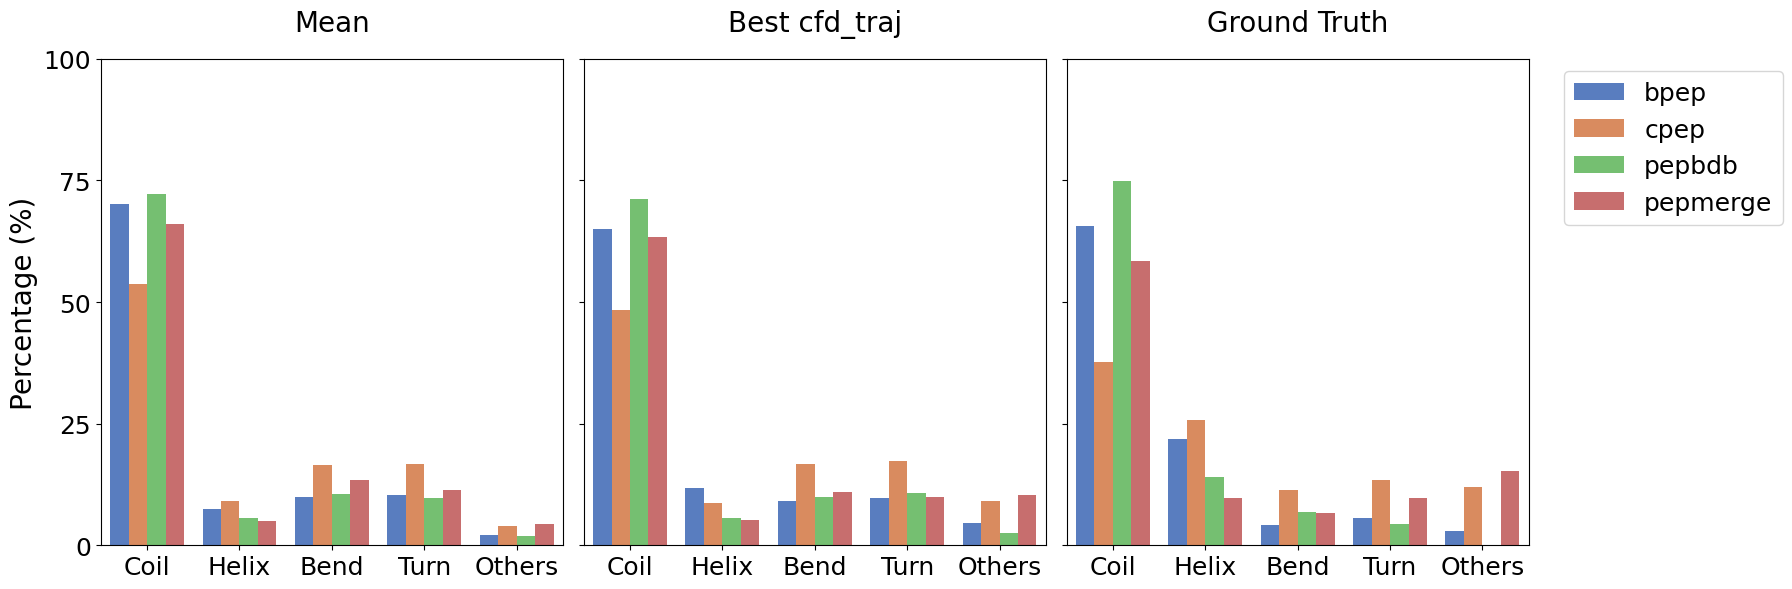

In [26]:
ss_order = ['Coil', 'Helix', 'Bend', 'Turn', 'Others']
# sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

plot_datasets = [
    ("Mean", df_pred_mean, axes[0]),
    ("Best cfd_traj", df_pred_best_cfd, axes[1]),
    ("Ground Truth", df_gt, axes[2])
]

for i, (title, data, ax) in enumerate(plot_datasets):
    # 绘图：x为结构类型，hue为db分组
    sns.barplot(
        data=data,
        x='SS_Type',
        y='Percentage',
        hue='db',
        order=ss_order,
        palette='muted',
        ax=ax
    )
        
    # 细节设置
    ax.set_title(title, fontsize=20, pad=20)
    ax.set_xlabel('', fontsize=16)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_ylim(0, 100)
    ax.tick_params(axis='both', labelsize=18)
    
    # 只有左侧图保留 Y 轴标签
    if ax == axes[0]:
        ax.set_ylabel('Percentage (%)', fontsize=20)
    else:
        ax.set_ylabel('')

    if i < 2:
        # 前两个图去掉图例
        if ax.get_legend():
            ax.get_legend().remove()
    else:
        # 最后一个图保留图例并放到右侧外
        ax.legend(title='', loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=18)

plt.tight_layout()
plt.savefig('./metric_stat/pepdesign_ss_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### Ramachandran

In [27]:
rama_stat_list = ['total_angle_numbers', 'total_accept', 'total_favoured']
rama_stat_list_gt = [col+'_gt' for col in rama_stat_list]

In [28]:
def cal_rama_stats(df_metric):
    df_rama_stats = df_metric.groupby('db')[['total_angle_numbers', 'total_accept', 'total_favoured']].sum().reset_index()
    df_rama_stats['favoured_ratio'] = (df_rama_stats['total_favoured'] / df_rama_stats['total_angle_numbers']) * 100
    df_rama_stats['accept_ratio'] = (df_rama_stats['total_accept'] / df_rama_stats['total_angle_numbers']) * 100
    return df_rama_stats

In [29]:
# best cfd_traj
idx = df_gen_merge.groupby('data_id')['cfd_traj'].idxmax() # index with max cfd_traj
df_merge_best_cfd = df_gen_merge.loc[idx, ['data_id', 'db', 'cfd_traj'] + rama_stat_list].reset_index(drop=True)

In [30]:
# ground truth - 保留所有数据, 不能被tag过滤
df_rama_gt_full = df_gen_merge_full[['data_id', 'db']+rama_stat_list_gt].drop_duplicates()
# remove '_gt' in column names
df_rama_gt_full.columns = df_rama_gt_full.columns.str.replace('_gt', '')

In [31]:
df_rama_stats_mean = cal_rama_stats(df_gen_merge)
df_rama_stats_best_cfd = cal_rama_stats(df_merge_best_cfd)
df_rama_stats_gt = cal_rama_stats(df_rama_gt_full)

In [32]:
suffix_map = [
    (df_rama_stats_mean, "_mean"),
    (df_rama_stats_best_cfd, "_best_cfd"),
    (df_rama_stats_gt, "_gt"),
]
stat_cols = ["accept_ratio", "favoured_ratio"]

blocks = [
    df.set_index("db")[stat_cols].add_suffix(suffix)
    for df, suffix in suffix_map
]

df_rama_combined = pd.concat(blocks, axis=1).reset_index()

In [33]:
ratio_cols = [col for col in df_rama_combined.columns if col != 'db']
for col in ratio_cols:
    df_rama_combined[col] = df_rama_combined[col].apply(lambda x: f"{x:.2f}%")

In [59]:
# df_rama_combined = pd.merge(
#     df_rama_stats_mean[['db', 'accept_ratio', 'favoured_ratio']], 
#     df_rama_stats_best_cfd[['db', 'accept_ratio', 'favoured_ratio']], 
#     on='db', 
#     suffixes=('_mean', '_best_cfd')
# )

# df_rama_combined = pd.merge(
#     df_rama_combined,
#     df_rama_stats_gt[['db', 'accept_ratio', 'favoured_ratio']],
#     on='db',
#     suffixes=('', '_gt')
# )

In [34]:
df_rama_combined

,db,accept_ratio_mean,favoured_ratio_mean,accept_ratio_best_cfd,favoured_ratio_best_cfd,accept_ratio_gt,favoured_ratio_gt
0,bpep,72.44%,53.08%,81.74%,62.96%,99.11%,93.74%
1,cpep,68.78%,46.17%,77.03%,58.11%,100.00%,93.40%
2,pepbdb,72.59%,53.69%,77.08%,61.26%,99.60%,94.07%
3,pepmerge,71.39%,51.23%,80.00%,63.59%,98.77%,93.14%


In [35]:
df_rama_combined.to_csv('./metric_stat/pepdesign_rama_stats.csv', index=False)

### PLIP interaction

In [36]:
plip_inter_list = ['hydrophobic_interactions', 'hydrogen_bonds', 'water_bridges', 'salt_bridges', 
                   'pi_stacks', 'pi_cation_interactions', 'halogen_bonds', 'metal_complexes']

In [37]:
def load_plip(gen_dir):

    df_plip = pd.read_csv(os.path.join(gen_dir, 'plip_interactions.csv'))
    df_plip_gt = pd.read_csv(os.path.join(gen_dir, 'plip_interactions_gt.csv'))

    # remove failed pepdesign: tag is not np.nan
    count_all = df_plip.shape[0]
    df_plip = df_plip[df_plip['tag'].isna()]
    print('Dropped %d rows with failed pepdesign' % (count_all - df_plip.shape[0]))

    for col in plip_inter_list:
        df_plip[col+'_ratio'] = df_plip[col] / df_plip['num_interactions']
        df_plip_gt[col+'_ratio'] = df_plip_gt[col] / df_plip_gt['num_interactions']

    return df_plip, df_plip_gt

In [38]:
def metric_stat_plip(df_plip, db_name, mode="mean"):
    
    target_cols = [col+'_ratio' for col in plip_inter_list]

    if mode in ["mean", "gt"]:
        # Metrics-1: by mean of each data_id
        df_stat = pd.DataFrame(df_plip[target_cols].mean(), columns=[db_name])
    elif mode == "best_cfd":
        # Metrics-2: by max cfd_traj of each data_id
        idx = df_plip.groupby('data_id')['cfd_traj'].idxmax() # index with max cfd_traj
        df_best_cfd = df_plip.loc[idx, ['data_id', 'db', 'cfd_traj'] + target_cols].reset_index(drop=True)
        df_stat = pd.DataFrame(df_best_cfd[target_cols].mean(), columns=[db_name])
    elif mode == "median":
        df_stat = pd.DataFrame(df_plip[target_cols].median(), columns=[db_name])
    else:
        raise ValueError("Invalid mode.")

    return df_stat

In [39]:
gen_dir_bpep = './outputs_test/pepdesign_bpep/base_pxm_20260325_130808'
df_bpep_plip, df_bpep_plip_gt = load_plip(gen_dir_bpep)

Dropped 7033 rows with failed pepdesign


In [40]:
gen_dir_cpep = './outputs_test/pepdesign_cpep/base_pxm_20260328_141105'
df_cpep_plip, df_cpep_plip_gt = load_plip(gen_dir_cpep)

Dropped 4364 rows with failed pepdesign


In [41]:
gen_dir_pepbdb = './outputs_test/pepdesign_pepbdb/base_pxm_20260325_130506'
df_pepbdb_plip, df_pepbdb_plip_gt = load_plip(gen_dir_pepbdb)

Dropped 2217 rows with failed pepdesign


In [42]:
gen_dir_pepmerge = './outputs_test/pepdesign_pepmerge/base_pxm_20260407_132739'
df_pepmerge_plip, df_pepmerge_plip_gt = load_plip(gen_dir_pepmerge)

Dropped 14643 rows with failed pepdesign


In [43]:
db_list = ['bpep', 'cpep', 'pepbdb', 'pepmerge']
df_list = [df_bpep_plip, df_cpep_plip, df_pepbdb_plip, df_pepmerge_plip]
df_gt_list = [df_bpep_plip_gt, df_cpep_plip_gt, df_pepbdb_plip_gt, df_pepmerge_plip_gt]

df_plip_mean = pd.DataFrame()
df_plip_best_cfd = pd.DataFrame()
df_plip_gt = pd.DataFrame()
for db, df, df_gt in zip(db_list, df_list, df_gt_list):
    # stat
    df_stat_mean = metric_stat_plip(df, db, mode="mean")
    df_stat_best_cfd = metric_stat_plip(df, db, mode="best_cfd")
    df_stat_gt = metric_stat_plip(df_gt, db, mode="gt")
    # concat
    df_plip_mean = pd.concat([df_plip_mean, df_stat_mean], axis=1)
    df_plip_best_cfd = pd.concat([df_plip_best_cfd, df_stat_best_cfd], axis=1)
    df_plip_gt = pd.concat([df_plip_gt, df_stat_gt], axis=1)

# to percent
df_plip_mean = df_plip_mean.applymap(lambda x: f"{x*100:.2f}%")
df_plip_best_cfd = df_plip_best_cfd.applymap(lambda x: f"{x*100:.2f}%")
df_plip_gt = df_plip_gt.applymap(lambda x: f"{x*100:.2f}%")

In [44]:
df_plip_mean.T

,hydrophobic_interactions_ratio,hydrogen_bonds_ratio,water_bridges_ratio,salt_bridges_ratio,pi_stacks_ratio,pi_cation_interactions_ratio,halogen_bonds_ratio,metal_complexes_ratio
bpep,46.79%,43.00%,0.00%,7.82%,1.11%,1.28%,0.00%,0.00%
cpep,53.61%,35.94%,0.00%,7.26%,2.38%,0.81%,0.00%,0.00%
pepbdb,49.22%,41.69%,0.00%,6.57%,1.76%,0.76%,0.00%,0.00%
pepmerge,45.81%,42.80%,0.00%,8.59%,1.22%,1.58%,0.00%,0.00%


In [45]:
df_plip_best_cfd.T

,hydrophobic_interactions_ratio,hydrogen_bonds_ratio,water_bridges_ratio,salt_bridges_ratio,pi_stacks_ratio,pi_cation_interactions_ratio,halogen_bonds_ratio,metal_complexes_ratio
bpep,47.08%,43.73%,0.00%,6.82%,0.90%,1.47%,0.00%,0.00%
cpep,51.48%,42.07%,0.00%,5.78%,0.67%,0.00%,0.00%,0.00%
pepbdb,49.75%,42.49%,0.00%,4.94%,1.99%,0.81%,0.00%,0.00%
pepmerge,44.71%,42.87%,0.00%,9.28%,1.23%,1.92%,0.00%,0.00%


In [46]:
df_plip_gt.T

,hydrophobic_interactions_ratio,hydrogen_bonds_ratio,water_bridges_ratio,salt_bridges_ratio,pi_stacks_ratio,pi_cation_interactions_ratio,halogen_bonds_ratio,metal_complexes_ratio
bpep,45.13%,43.92%,0.00%,8.23%,0.89%,1.84%,0.00%,0.00%
cpep,53.83%,33.16%,0.00%,7.80%,4.65%,0.55%,0.00%,0.00%
pepbdb,44.25%,46.00%,0.00%,7.65%,1.22%,0.88%,0.00%,0.00%
pepmerge,45.31%,41.68%,0.00%,10.03%,0.36%,2.62%,0.00%,0.00%


In [47]:
df_plip_mean.T.to_csv('./metric_stat/pepdesign_plip_mean.csv', index=True)
df_plip_best_cfd.T.to_csv('./metric_stat/pepdesign_plip_best_cfd.csv', index=True)
df_plip_gt.T.to_csv('./metric_stat/pepdesign_plip_gt.csv', index=True)

### Vina score

In [48]:
def calc_metric_stat(df_metric, db_name, target_cols, mode="mean"):
    
    """
    suitable for plip interaction, vina score, rosetta dG
    """
    if mode in ["mean", "gt"]:
        # Metrics-1: by mean of each data_id
        df_metric = df_metric.copy()
    elif mode == "best_cfd":
        # Metrics-2: by max cfd_traj of each data_id
        idx = df_metric.groupby('data_id')['cfd_traj'].idxmax() # index with max cfd_traj
        df_best_cfd = df_metric.loc[idx, ['data_id', 'db', 'cfd_traj'] + target_cols].reset_index(drop=True)
        df_metric = df_best_cfd.copy()
    elif mode == "min":
        # Metrics-3: by oracle (min) of each data_id
        df_min = df_metric.groupby('data_id')[target_cols].min()
        df_metric = df_min.copy()
    elif mode == "max":
        # Metrics-3: by oracle (max) of each data_id
        df_max = df_metric.groupby('data_id')[target_cols].max()
        df_metric = df_max.copy()
    
    df_stat = pd.DataFrame(df_metric[target_cols].mean(), columns=[db_name])

    return df_stat, df_metric

In [49]:
def load_vina(gen_dir):

    df_vina = pd.read_csv(os.path.join(gen_dir, 'vina_score.csv'))
    df_vina_gt = pd.read_csv(os.path.join(gen_dir, 'vina_score_gt.csv'))

    # remove failed pepdesign: tag is not np.nan
    count_all = df_vina.shape[0]
    df_vina = df_vina[df_vina['tag'].isna()]
    print('Dropped %d rows with failed pepdesign' % (count_all - df_vina.shape[0]))

    return df_vina, df_vina_gt

In [50]:
gen_dir_bpep = './outputs_test/pepdesign_bpep/base_pxm_20260325_130808'
df_bpep_vina, df_bpep_vina_gt = load_vina(gen_dir_bpep)

Dropped 7033 rows with failed pepdesign


In [51]:
gen_dir_cpep = './outputs_test/pepdesign_cpep/base_pxm_20260328_141105'
df_cpep_vina, df_cpep_vina_gt = load_vina(gen_dir_cpep)

Dropped 4364 rows with failed pepdesign


In [52]:
gen_dir_pepbdb = './outputs_test/pepdesign_pepbdb/base_pxm_20260325_130506'
df_pepbdb_vina, df_pepbdb_vina_gt = load_vina(gen_dir_pepbdb)

Dropped 2217 rows with failed pepdesign


In [53]:
gen_dir_pepmerge = './outputs_test/pepdesign_pepmerge/base_pxm_20260407_132739'
df_pepmerge_vina, df_pepmerge_vina_gt = load_vina(gen_dir_pepmerge)

Dropped 14643 rows with failed pepdesign


In [56]:
target_cols=['vina_score']
db_list = ['bpep', 'cpep', 'pepbdb', 'pepmerge']
df_list = [df_bpep_vina, df_cpep_vina, df_pepbdb_vina, df_pepmerge_vina]
df_gt_list = [df_bpep_vina_gt, df_cpep_vina_gt, df_pepbdb_vina_gt, df_pepmerge_vina_gt]

df_vina_mean = pd.DataFrame()
df_vina_best_cfd = pd.DataFrame()
df_vina_oracle = pd.DataFrame()
df_vina_gt = pd.DataFrame()
df_vina_oracle_list = []
df_vina_gt_list = []
for db, df_metric, df_metric_gt in zip(db_list, df_list, df_gt_list):
    # stat
    df_stat_mean, _ = calc_metric_stat(df_metric, db, target_cols, mode="mean")
    df_stat_best_cfd, _ = calc_metric_stat(df_metric, db, target_cols, mode="best_cfd")
    df_stat_oracle, df_oracle = calc_metric_stat(df_metric, db, target_cols, mode="min")
    df_stat_gt, df_gt = calc_metric_stat(df_metric_gt, db, target_cols, mode="gt")
    # concat
    df_vina_mean = pd.concat([df_vina_mean, df_stat_mean], axis=1)
    df_vina_best_cfd = pd.concat([df_vina_best_cfd, df_stat_best_cfd], axis=1)
    df_vina_oracle = pd.concat([df_vina_oracle, df_stat_oracle], axis=1)
    df_vina_gt = pd.concat([df_vina_gt, df_stat_gt], axis=1)
    # append oracle
    df_vina_oracle_list.append(df_oracle)
    df_vina_gt_list.append(df_gt)

In [57]:
df_vina_mean.index += '_mean'
df_vina_best_cfd.index += '_best_cfd'
df_vina_oracle.index += '_oracle'
df_vina_gt.index += '_gt'
df_vina_all = pd.concat([df_vina_mean.T, df_vina_best_cfd.T, df_vina_oracle.T, df_vina_gt.T], axis=1)
df_vina_all

,vina_score_mean,vina_score_best_cfd,vina_score_oracle,vina_score_gt
bpep,0.397511,-3.949809,-5.373816,-3.940101
cpep,12.299076,-3.160461,-4.587866,-4.419815
pepbdb,3.814097,4.715855,-5.618668,-4.009047
pepmerge,2.278599,-1.947017,-5.034431,-3.673933


In [58]:
df_vina_all.to_csv('./metric_stat/pepdesign_vina_stats.csv', index=True)

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_energy_score_distribution(df_list, db_names, col_name='dG', y_lim=None, output_path=None):
    """
    绘制 rosetta dG / vina score 分布箱线图和叠加散点
    参数:
        df_list: 包含各数据库 DataFrame 的列表，每个 DataFrame 必需有列 'dG'
        db_names: 各数据库名称列表，顺序与 df_list 匹配
        output_path: 可选，若给定则保存图片而非直接 show
    """
    combined_dfs = []
    for df, name in zip(df_list, db_names):
        temp_df = df[[col_name]].copy()
        temp_df['db'] = name
        combined_dfs.append(temp_df)
    df_all_score = pd.concat(combined_dfs, axis=0)
    df_all_score.dropna(subset=[col_name], inplace=True)

    # 设置默认风格
    sns.reset_orig()

    plt.figure(figsize=(8, 4))

    ax = sns.boxplot(
        data=df_all_score,
        x='db',
        y=col_name,
        palette='muted',
        showfliers=False,
        width=0.5,
        linewidth=1.2
    )

    sns.stripplot(
        data=df_all_score,
        x='db',
        y=col_name,
        color='0.3',
        size=3.5,
        alpha=0.4,
        jitter=True
    )

    for spine_name in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine_name].set_visible(True)
        ax.spines[spine_name].set_edgecolor('black')
        ax.spines[spine_name].set_linewidth(1.0)

    # ax.set_title('rosetta Score Distribution across Databases', fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('', fontsize=18)
    ax.set_ylabel(f'{col_name.replace("_", " ")}', fontsize=18)
    ax.tick_params(axis='both', labelsize=16)

    if y_lim is not None:
        ax.set_ylim(y_lim)
        # ax.set_yticks(np.arange(y_lim[0], y_lim[1]+1, 5))

    ax.grid(False)
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

In [60]:
db_names = ['bpep', 'cpep', 'pepbdb', 'pepmerge']

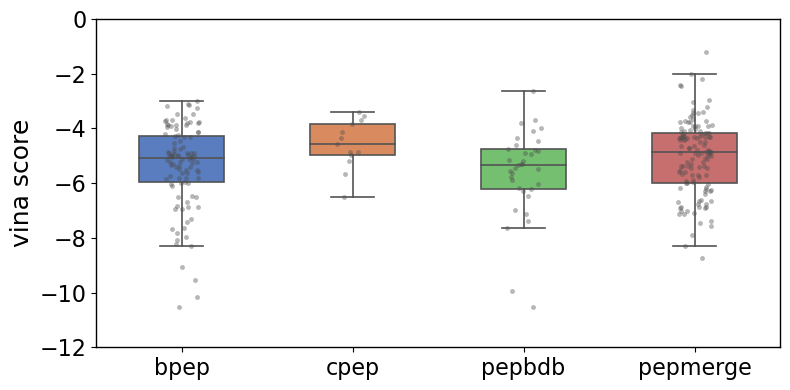

In [65]:
output_path = './metric_stat/pepdesign_vina_score_oracle.png'
plot_energy_score_distribution(df_vina_oracle_list, db_names, col_name='vina_score', y_lim=(-12, 0), output_path=output_path)

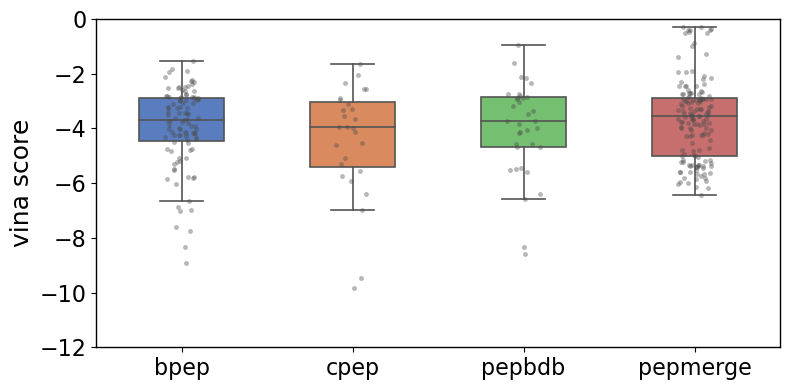

In [66]:
output_path = './metric_stat/pepdesign_vina_score_gt.png'
plot_energy_score_distribution(df_vina_gt_list, db_names, col_name='vina_score', y_lim=(-12, 0), output_path=output_path)

### Rosetta dG

In [78]:
def load_rosetta(gen_dir, db_name):
    with open(os.path.join(gen_dir, f'{db_name}_rosetta_dG_report_gen.jsonl'), 'r') as f:
        rosetta_dict = json.load(f)
    df_rosetta = pd.DataFrame([
        {"filename": k, "dG": v["min"]} for k, v in rosetta_dict.items()
    ])
    
    with open(os.path.join(gen_dir, f'{db_name}_rosetta_dG_report_gt.jsonl'), 'r') as f:
        rosetta_dict = json.load(f)
    df_rosetta_gt = pd.DataFrame([
        {"filename": k, "dG": v["min"]} for k, v in rosetta_dict.items()
    ])
    
    df_gen = pd.read_csv(os.path.join(gen_dir, 'gen_info.csv'))

    # remove failed pepdesign: tag is not np.nan
    count_all = df_gen.shape[0]
    df_gen = df_gen[df_gen['tag'].isna()]
    print('Dropped %d rows with failed pepdesign' % (count_all - df_gen.shape[0]))

    # merge
    df_rosetta['key'] = df_rosetta['filename'].str.split(r'[_\.]').str[0]
    df_gen['key'] = df_gen['filename'].str.split(r'[_\.]').str[0]
    df_gen_merge = pd.merge(df_gen, df_rosetta, on='key', how='left')

    df_gen_merge.drop(columns=['key', 'filename_y'], inplace=True)
    df_gen_merge.rename(columns={'filename_x': 'filename'}, inplace=True)

    # filter
    count_all = df_gen_merge.shape[0]
    df_gen_merge = df_gen_merge[df_gen_merge['dG'] < 10000]
    print('Generate Data: Dropped %d rows with dG > 10000' % (count_all - df_gen_merge.shape[0]))

    # filter
    count_all = df_rosetta_gt.shape[0]
    df_rosetta_gt = df_rosetta_gt[df_rosetta_gt['dG'] < 10000]
    print('Ground Truth: Dropped %d rows with dG > 10000' % (count_all - df_rosetta_gt.shape[0]))

    return df_gen_merge, df_rosetta_gt
    

In [79]:
gen_dir_bpep = './outputs_test/pepdesign_bpep/base_pxm_20260325_130808'
df_bpep_rosetta, df_bpep_rosetta_gt = load_rosetta(gen_dir_bpep, 'bpep')

Dropped 7033 rows with failed pepdesign
Generate Data: Dropped 0 rows with dG > 10000
Ground Truth: Dropped 0 rows with dG > 10000


In [80]:
gen_dir_cpep = './outputs_test/pepdesign_cpep/base_pxm_20260328_141105'
df_cpep_rosetta, df_cpep_rosetta_gt = load_rosetta(gen_dir_cpep, 'cpep')

Dropped 4364 rows with failed pepdesign
Generate Data: Dropped 0 rows with dG > 10000
Ground Truth: Dropped 1 rows with dG > 10000


In [81]:
gen_dir_pepbdb = './outputs_test/pepdesign_pepbdb/base_pxm_20260325_130506'
df_pepbdb_rosetta, df_pepbdb_rosetta_gt = load_rosetta(gen_dir_pepbdb, 'pepbdb')

Dropped 2217 rows with failed pepdesign
Generate Data: Dropped 0 rows with dG > 10000
Ground Truth: Dropped 0 rows with dG > 10000


In [82]:
gen_dir_pepmerge = './outputs_test/pepdesign_pepmerge/base_pxm_20260407_132739'
df_pepmerge_rosetta, df_pepmerge_rosetta_gt = load_rosetta(gen_dir_pepmerge, 'pepmerge')

Dropped 14643 rows with failed pepdesign
Generate Data: Dropped 0 rows with dG > 10000
Ground Truth: Dropped 0 rows with dG > 10000


In [83]:
target_cols=['dG']
db_list = ['bpep', 'cpep', 'pepbdb', 'pepmerge']
df_list = [df_bpep_rosetta, df_cpep_rosetta, df_pepbdb_rosetta, df_pepmerge_rosetta]
df_gt_list = [df_bpep_rosetta_gt, df_cpep_rosetta_gt, df_pepbdb_rosetta_gt, df_pepmerge_rosetta_gt]

df_rosetta_mean = pd.DataFrame()
df_rosetta_best_cfd = pd.DataFrame()
df_rosetta_oracle = pd.DataFrame()
df_rosetta_gt = pd.DataFrame()
df_rosetta_oracle_list = []
df_rosetta_gt_list = []
for db, df_metric, df_metric_gt in zip(db_list, df_list, df_gt_list):
    # stat
    df_stat_mean, _ = calc_metric_stat(df_metric, db, target_cols, mode="mean")
    df_stat_best_cfd, _ = calc_metric_stat(df_metric, db, target_cols, mode="best_cfd")
    df_stat_oracle, df_oracle = calc_metric_stat(df_metric, db, target_cols, mode="min")
    df_stat_gt, df_gt = calc_metric_stat(df_metric_gt, db, target_cols, mode="gt")
    # concat
    df_rosetta_mean = pd.concat([df_rosetta_mean, df_stat_mean], axis=1)
    df_rosetta_best_cfd = pd.concat([df_rosetta_best_cfd, df_stat_best_cfd], axis=1)
    df_rosetta_oracle = pd.concat([df_rosetta_oracle, df_stat_oracle], axis=1)
    df_rosetta_gt = pd.concat([df_rosetta_gt, df_stat_gt], axis=1)
    # append oracle
    df_rosetta_oracle_list.append(df_oracle)
    df_rosetta_gt_list.append(df_gt)

In [84]:
df_rosetta_mean.index += '_mean'
df_rosetta_best_cfd.index += '_best_cfd'
df_rosetta_oracle.index += '_oracle'
df_rosetta_gt.index += '_gt'
df_rosetta_all = pd.concat([df_rosetta_mean.T, df_rosetta_best_cfd.T, df_rosetta_oracle.T, df_rosetta_gt.T], axis=1)
df_rosetta_all

,dG_mean,dG_best_cfd,dG_oracle,dG_gt
bpep,67.073300,-27.420929,-42.261077,-37.513013
cpep,265.292955,-29.090496,-40.001282,-29.814173
pepbdb,133.684036,104.777856,-39.418486,-36.510773
pepmerge,98.759328,-22.798891,-36.333579,-34.737428


In [85]:
df_rosetta_all.to_csv('./metric_stat/pepdesign_rosetta_stats.csv', index=True)

In [86]:
db_names = ['bpep', 'cpep', 'pepbdb', 'pepmerge']

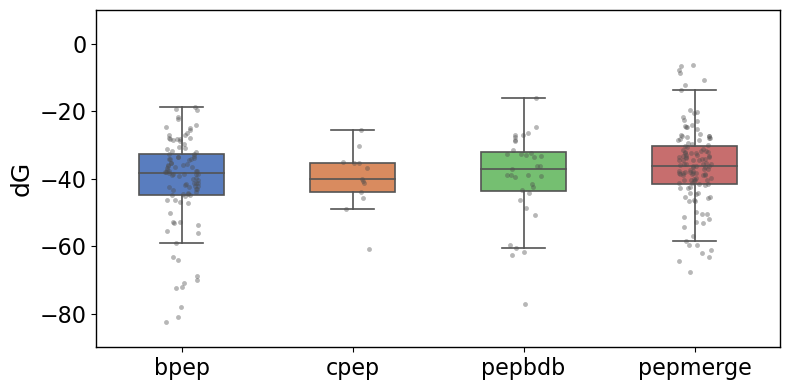

In [91]:
output_path = './metric_stat/pepdesign_rosetta_dG_oracle.png'
plot_energy_score_distribution(df_rosetta_oracle_list, db_names, col_name='dG', y_lim=(-90, 10), output_path=output_path)

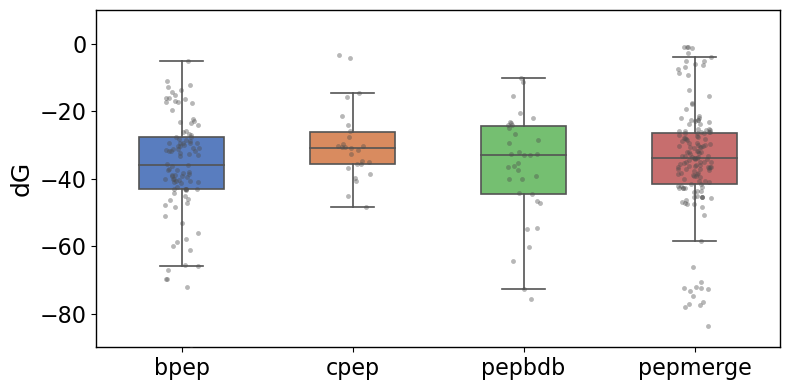

In [92]:
output_path = './metric_stat/pepdesign_rosetta_dG_gt.png'
plot_energy_score_distribution(df_rosetta_gt_list, db_names, col_name='dG', y_lim=(-90, 10), output_path=output_path)

### Diversity & Novelty

In [ ]:
# python ~/PocketXMol/evaluate/check_unique.py -i clu_gen_cluster.tsv -o clu_gen_cluster_unique.tsv

In [93]:
def calc_diversity(input_path, output_path=None, encoding='utf-8'):
    """
    Ref: evaluate/check_unique.py
    
    Calculate FoldSeek Diversity:
    the number of clusters divided by the number of complexes. 
    """
    
    unique_values = set()

    with open(input_path, 'r', encoding=encoding) as infile:
        for line_num, line in enumerate(infile, 1):
            line = line.rstrip('\n')
            first_col = line.split('\t', 1)[0]
            unique_values.add(first_col)
            
            if line_num % 100000 == 0:
                print(f"Processed {line_num} lines, current unique values count: {len(unique_values)}")
    
    # with open(output_path, 'w', encoding=encoding) as outfile:
    #     for value in unique_values:
    #         outfile.write(f"{value}\n")
    
    # print(f"Processing completed! Total lines processed: {line_num}, final unique values count: {len(unique_values)}")
    # print(f"Results saved to: {output_path}")
    return len(unique_values) / line_num

In [94]:
import csv

def calc_novelty(file_path, ignore_R=False, ignore_same_id=False, overlap_threshold=4, column=3):
    """
    Ref: evaluate/check_qtm_max_average.py
    
    Columns: query,target,complexqtmscore,complexttmscore,lddt

    Calculate FoldSeek Novelty:
    1. select the highest qTm value (Tm normalized by query, complexqtmscore) of peptides
    2. calculate their average across all complexes
    3. define novelty as 1-(average highest qTm)
    """

    max_values = {}  # key: first column value, value: (max value, entire row data)
    
    with open(file_path, 'r', encoding='utf-8', newline='') as file:
        reader = csv.reader(file, delimiter='\t')
        
        for row_num, row in enumerate(reader, 1):
            # if row_num % 1000000 == 0:
            #     print(f"Processed {row_num:,} rows...", file=sys.stderr)
            
            if len(row) < column:
                print(f"Warning: Row {row_num} has fewer than {column} columns, skipped", file=sys.stderr)
                continue
            
            key = row[0] # query id
            second_col = row[1] if len(row) > 1 else ""
            
            if ignore_same_id:
                key_prefix = key.split('_', 1)[0] if '_' in key else key
                key_prefix_overlap = key_prefix[:overlap_threshold]
                
                second_col_prefix = second_col.split('-', 1)[0] if '-' in second_col else second_col
                second_col_prefix_overlap = second_col_prefix[:overlap_threshold]
                
                if key_prefix_overlap == second_col_prefix_overlap:
                    continue
            
            if ignore_R: # ignore receptor (R), focus on peptides
                last_underscore_idx = key.rfind('_')
                if last_underscore_idx != -1 and last_underscore_idx < len(key) - 1:
                    suffix = key[last_underscore_idx + 1:]
                    if suffix == 'R':
                        continue
            
            try:
                value_str = row[column - 1].replace('^@', '').strip() # column=3, Default: complexqtmscore (qTm)
                value = float(value_str)
            except ValueError:
                print(f"Warning: Row {row_num} column {column} '{row[column - 1]}' is not a valid number, skipped", file=sys.stderr)
                continue
            
            if key not in max_values or value > max_values[key][0]: # max qTm for each query
                max_values[key] = (value, row)
        
        all_max_values = [item[0] for item in max_values.values()]
        
        average = sum(all_max_values) / len(all_max_values)

        return 1 - average

In [95]:
gen_dir_bpep = './outputs_test/pepdesign_bpep/base_pxm_20260325_130808'
gen_dir_cpep = './outputs_test/pepdesign_cpep/base_pxm_20260328_141105'
gen_dir_pepbdb = './outputs_test/pepdesign_pepbdb/base_pxm_20260325_130506'
gen_dir_pepmerge = './outputs_test/pepdesign_pepmerge/base_pxm_20260407_132739'

In [96]:
db_list = ['bpep', 'cpep', 'pepbdb', 'pepmerge']
gen_dir_list = [gen_dir_bpep, gen_dir_cpep, gen_dir_pepbdb, gen_dir_pepmerge]

In [100]:
div_gen_list = []
div_best_cfd_list = []
div_gt_list = []
for gen_dir, db in zip(gen_dir_list, db_list):
    
    div_gen = calc_diversity(os.path.join(gen_dir, f'foldseek_output/clu_gen_cluster.tsv'))
    div_best_cfd = calc_diversity(os.path.join(gen_dir, f'foldseek_output/clu_best_cfd_cluster.tsv'))
    div_gt = calc_diversity(os.path.join(gen_dir, f'foldseek_output/clu_gt_cluster.tsv'))
    div_gen_list.append(div_gen)
    div_best_cfd_list.append(div_best_cfd)
    div_gt_list.append(div_gt)

df_diversity = pd.DataFrame({'db': db_list, 'div_gen': div_gen_list, 'div_best_cfd': div_best_cfd_list, 'div_gt': div_gt_list})
df_diversity.set_index('db', inplace=True)
df_diversity # div_gen明显低于div_gt: generate时num_repeat=200, 分母较大 

,div_gen,div_best_cfd,div_gt
db,,,
bpep,0.332086,0.970588,0.823529
cpep,0.731894,1.000000,0.888889
pepbdb,0.328246,1.000000,0.942857
pepmerge,0.354757,0.685039,0.273333


In [101]:
df_diversity.to_csv('./metric_stat/pepdesign_diversity_stats.csv', index=True)

In [102]:
nov_gen_list = []
nov_best_cfd_list = []
nov_gt_list = []
for gen_dir, db in zip(gen_dir_list, db_list):
    if db in ['bpep', 'pepbdb']:
        search_db = 'pepbdb'
    elif db == 'cpep':
        search_db = 'cpsea'

    nov_gen = calc_novelty(os.path.join(gen_dir, f'foldseek_output/search_{search_db}_gen'), ignore_R=True, column=3)
    nov_best_cfd = calc_novelty(os.path.join(gen_dir, f'foldseek_output/search_{search_db}_best_cfd'), ignore_R=True, column=3)
    nov_gt = calc_novelty(os.path.join(gen_dir, f'foldseek_output/search_{search_db}_gt'), ignore_R=True, column=3)
    nov_gen_list.append(nov_gen)
    nov_best_cfd_list.append(nov_best_cfd)
    nov_gt_list.append(nov_gt)

df_novelty = pd.DataFrame({'db': db_list, 'nov_gen': nov_gen_list, 'nov_best_cfd': nov_best_cfd_list, 'nov_gt': nov_gt_list})
df_novelty.set_index('db', inplace=True)
df_novelty

,nov_gen,nov_best_cfd,nov_gt
db,,,
bpep,0.376123,0.385545,0.354081
cpep,0.809036,0.796261,0.779287
pepbdb,0.421510,0.392590,0.441412
pepmerge,0.321414,0.294114,0.279755


In [103]:
df_novelty.to_csv('./metric_stat/pepdesign_novelty_stats.csv', index=True)

### Correlation

In [104]:
def merge_data(df_total, df_temp, columns):
    key_col = 'filename_key'
    
    df_total[key_col] = df_total['db'] + '_' + df_total['filename'].astype(str).str.split(r'[-_\.]').str[0] # '_' for _gt.pdb in rama_stat_gt.csv / vina_score_gt.csv
    df_temp[key_col] = df_temp['db'] + '_' + df_temp['filename'].astype(str).str.split(r'[-_\.]').str[0]

    df_total = df_total.merge(
        df_temp[[key_col] + columns],
        on=key_col,
        how='left',
        validate='one_to_one' # check if the merge is one-to-one
    )
    
    df_total.drop(columns=[key_col], inplace=True)

    return df_total


In [105]:
df_vina_merge = pd.concat([df_bpep_vina, df_cpep_vina, df_pepbdb_vina, df_pepmerge_vina], axis=0)
df_rosetta_merge = pd.concat([df_bpep_rosetta, df_cpep_rosetta, df_pepbdb_rosetta, df_pepmerge_rosetta], axis=0)

In [106]:
# success样本: tag = np.nan
df_gen_merge = merge_data(df_gen_merge, df_vina_merge, columns=['vina_score'])
df_gen_merge = merge_data(df_gen_merge, df_rosetta_merge, columns=['dG'])

In [107]:
cols = [
    'cfd_traj', 'rmsd_ca_ta', 'rmsd_ca_ba', 'tmscore', 
    'seq_iden', 'rmsd_bb', 'accept_rate', 'favoured_rate', 
    'vina_score', 'dG'
]

# 确保数据为数值型并计算相关矩阵 (默认使用 pearson)
corr_matrix = df_gen_merge[cols].corr(method='pearson')

# 如果你想看等级相关，可以改用 method='spearman'
# corr_matrix = df_gen_merge[cols].corr(method='spearman')

In [108]:
rename_dict = {
    'cfd_traj': 'cfd_traj',
    'rmsd_ca_ta': 'RMSD CA-TA',
    'rmsd_ca_ba': 'RMSD CA-BA',
    'tmscore': 'TM-Score',
    'seq_iden': 'Sequence Recovery Rate',
    'rmsd_bb': 'Backbone RMSD',
    'accept_rate': 'Rama Accept Rate',
    'favoured_rate': 'Rama Favoured Rate',
    'vina_score': 'Vina Score',
    'dG': 'Rosetta dG'
}

In [109]:
corr_matrix.rename(columns=rename_dict, inplace=True)
corr_matrix.rename(index=rename_dict, inplace=True)

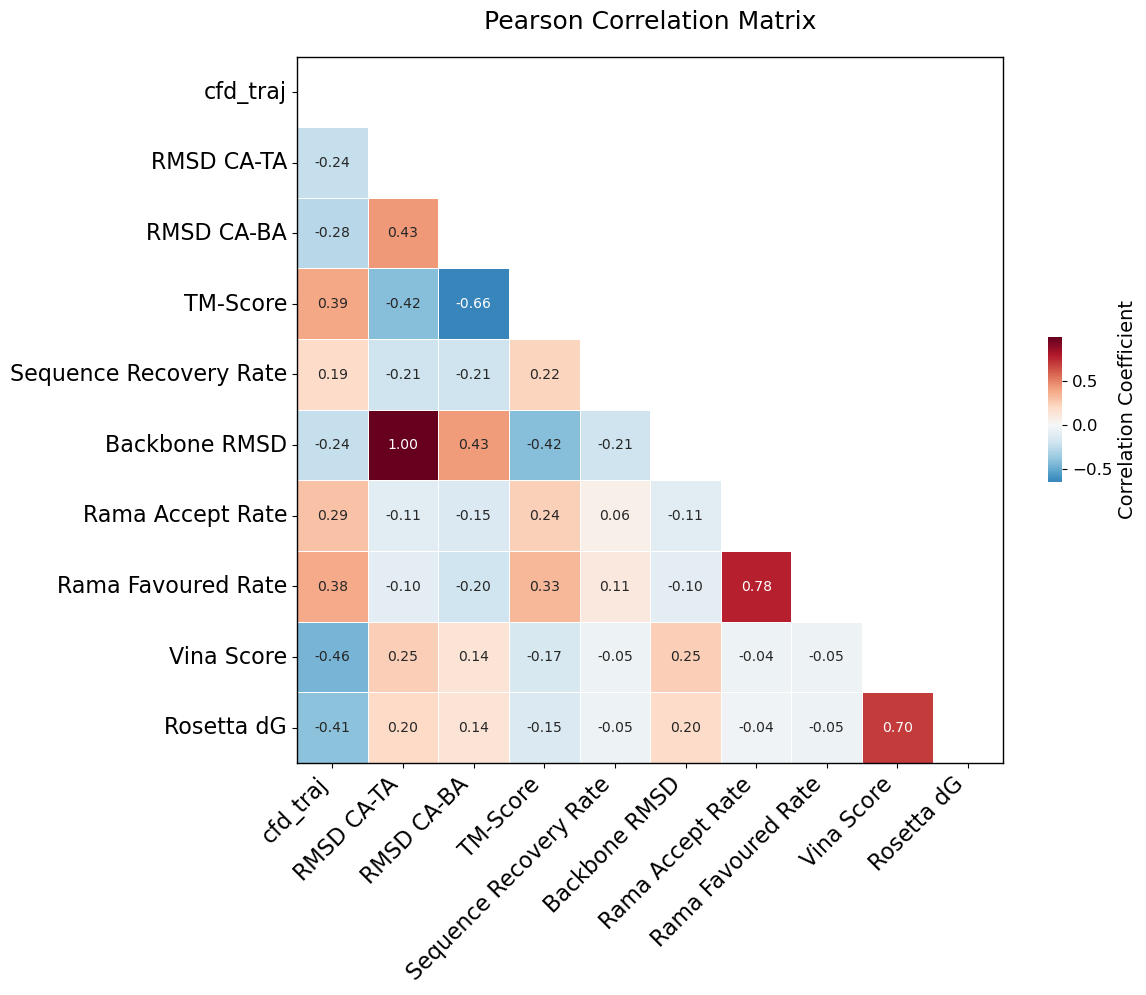

In [110]:
# 设置绘图尺寸
plt.figure(figsize=(12, 10))

# 创建掩码（Mask）以隐藏右上角的重复部分（可选，使图表更清爽）
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 绘制热图
ax = sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True,           # 显示数值
    fmt=".2f",            # 保留两位小数
    cmap='RdBu_r',        # 红蓝配色：红色正相关，蓝色负相关
    center=0,             # 设置 0 为颜色中心
    square=True,          # 每个格子为正方形
    linewidths=.5,        # 格子间距
    cbar_kws={
        "shrink": 0.2,       # 调整整体高度缩放（0.5 表示高度减半）
        "aspect": 10,        # 调整长宽比（数值越大，颜色条越细）
        "label": "Correlation Coefficient" # 颜色条标题
    }
)

# --- 强化边框设置 ---
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_edgecolor('black')
    spine.set_linewidth(1.0)

# 设置标签和标题
ax.set_title('Pearson Correlation Matrix', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=16)
plt.yticks(rotation=0, fontsize=16)
# 设置colorbar
cbar_ax = ax.figure.axes[-1] # 获取colorbar对象, 当前Figure的最后一张子图
cbar_ax.tick_params(labelsize=12)
cbar_ax.yaxis.label.set_size(14)

plt.tight_layout()

plt.savefig('./metric_stat/pepdesign_corr_matrix.png', dpi=300, bbox_inches='tight')
plt.show()